# Dusty Red Galaxies in COSMOS-Web
AP 2026

Fitting ALMA spectra and SED fitting


In [4]:
%load_ext autoreload
%autoreload 2

In [5]:
# imports
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl
import scipy
from utilities.cosmosWebHandler import CosmosWebHandler
from utilities.jadesHandler import JadesHandler
from utilities.catalogHandler import CatalogHandler

from astropy.table import Table
from astropy.io import fits
from utilities.almaA3Handler import AlmaA3Handler
from utilities.champsHandler import ChampsHandler
from utilities.mighteeHandler import MighteeHandler
from utilities.superDeblendedHandler import SuperDeblendedHandler
from utilities.jadesApertureEnum import JadesApertureEnum
from utilities.cosmosWebApertureEnum import CosmosWebApertureEnum
from utilities.bandEnum import BandEnum
from utilities.almaSpectraHandler import AlmaSpectraHandler

from utilities.utils import plot_alma_spectra, plot_alma_spectra_with_co_fit, plot_alma_spectra_with_h2o_fit, plot_alma_spectra_with_snr, include_scale_bar, include_interface_box, include_marker_scaled, include_ellipse_scaled, check_point_is_in_image, include_small_crosshair, plot_panel, get_statistics_with_sigma_clipping, get_peak_within_radius

from astropy.wcs import WCS
from astropy.io import fits
from astropy.table import Table
from astropy.coordinates import SkyCoord
import astropy.units as u
import fitz  # PyMuPDF
import os
from IPython.display import HTML
import pandas as pd

# silence noisy astropy WCS header-normalization warnings (DATE-*/OBSGEO-* datfix/obsfix, etc.)
import warnings
from astropy.wcs import FITSFixedWarning
warnings.simplefilter('ignore', FITSFixedWarning)

In [ ]:
# constants

PATH_PREFIX = '/Volumes/Apple SDXC Reader Media/dusty-red'
# PATH_PREFIX = '/scratch/poulin.al/dawn'

# CATALOG_PATH = f"{PATH_PREFIX}/data/COSMOSWeb_mastercatalog_v1.1.fits"
# CATALOG_LIGHT_PATH = f'{PATH_PREFIX}/data/COSMOSWeb_mastercatalog_v1.1_no_cigale_no_bd_no_ml_morpho_no_se_aper_no_galfitm_morpho.fits'  # a lighter version of the catalog with the cigale, bd, ml-morpho, se_aper, and galfitm-morpho columns removed to save space and load time, since we won't be using those columns in our analysis
CATALOG_LIGHTER_PATH = f'{PATH_PREFIX}/data/COSMOSWeb_mastercatalog_v1.1_no_cigale_no_bd_no_ml_morpho_no_se_aper_no_galfitm_morpho_lightphotom.fits'  # an even lighter version of the catalog with only the photometric columns (and the id, ra, dec columns) included, for quick loading when we only need the photometric data and not the lephare/cigale/bd/ml-morpho/se_aper/galfitm-morpho data
# CATALOG_LIGHTEST_PATH = f'{PATH_PREFIX}/data/COSMOSWeb_mastercatalog_v1.1_no_cigale_no_bd_no_ml_morpho_no_se_aper_no_galfitm_morpho_lightphotom_condition_clean_miri.fits'  # an even lighter version of the catalog with only the photometric columns (and the id, ra, dec columns) included, and only the objects that pass the condition_clean_miri cut included, for quick loading when we only need the photometric data for the objects that pass the condition_clean_miri cut.

DATA_DIR    = f'{PATH_PREFIX}/data'   # folder with the tiles
# (old) only needed if viewing the tile images of the catalog objects

CHAMPS_PRELIM_PRIOR_CATALOG = f'{PATH_PREFIX}/data/alma_prelim_catalog/Catalogs/champs_prior_catalog.fits'
CHAMPS_PRELIM_BLIND_CATALOG = f'{PATH_PREFIX}/data/alma_prelim_catalog/Catalogs/champs_blind_catalog.fits'
CHAMPS_IMAGE_MAP40 = f'{PATH_PREFIX}/data/alma_prelim_catalog/image_maps/champs_full_field_concat_split_pbcorr_40.fits'
CHAMPS_IMAGE_MAP20 = f'{PATH_PREFIX}/data/alma_prelim_catalog/image_maps/champs_full_field_concat_split_pbcorr_20.fits'
CHAMPS_IMAGE_MAP = f'{PATH_PREFIX}/data/alma_prelim_catalog/image_maps/champs_full_field_concat_split_image.fits'

MIGHTEE_CATALOG = f'{PATH_PREFIX}/data/mightee_continuum/MIGHTEE_Continuum_DR1_COSMOS_5p2arcsec_I_v1.1.fits'
L_BAND_IMAGE = f'{PATH_PREFIX}/data/mightee_continuum/COSMOS_XS_VLA_Lband.fits'
S_BAND_IMAGE = f'{PATH_PREFIX}/data/mightee_continuum/COSMOS_XS_VLA_Sband_img.fits'
VLA_3GHZ_IMAGE = f'{PATH_PREFIX}/data/mightee_continuum/vla_3ghz_msmf.fits'

SUPER_DEBLENDED_CATALOG = f'{PATH_PREFIX}/data/super-deblended/COSMOS_deblended_FIR_201821_photo_phys_2023June.fits'

S2COSP0762_ALMA_SPECTRA = f'{PATH_PREFIX}/alma-spectra/171478/S2COS0762_ALMA_stacked_spectra.txt'
S2COSP0762_ALMA_CLEAN = f'{PATH_PREFIX}/alma-spectra/171478/S2COS0762-CO54-clean.fits'

ALMA_A3_PRIOR_CATALOG = f'{PATH_PREFIX}/data/almaA3Cosmos/catalogues v20250312/A-COSMOS_prior_v20250312_Gaussian_with_meta_corrected_within_Pbcor_0.1_to_publish.fits'
ALMA_A3_BLIND_CATALOG = f'{PATH_PREFIX}/data/almaA3Cosmos/catalogues v20250312/A-COSMOS_blind_v20250312_PyBDSF_with_meta_corrected_within_Pbcor_0.1_with_combined_surveys_to_publish.fits'

# cosmos-web catalog

In [12]:
# load the handler
catalogHandler = CosmosWebHandler(CATALOG_LIGHTER_PATH)

catalogHandler.load_catalog(CATALOG_LIGHTER_PATH)

#read the cosmos web header
print("Reading the COSMOSWeb header...")
print(catalogHandler.hdr)


Filename: /Volumes/Apple SDXC Reader Media/dusty-red/data/COSMOSWeb_mastercatalog_v1.1_no_cigale_no_bd_no_ml_morpho_no_se_aper_no_galfitm_morpho_lightphotom.fits
No.    Name      Ver    Type      Cards   Dimensions   Format
  0  PRIMARY       1 PrimaryHDU       4   ()      
  1  PHOTOMETRY    1 BinTableHDU    107   784016R x 49C   [K, D, D, D, D, D, D, K, D, D, 5D, D, 5D, 5D, D, D, 5D, D, 5D, 5D, D, D, 5D, D, 5D, 5D, D, D, 5D, D, 5D, 5D, D, D, 5D, D, 5D, 5D, D, D, D, D, D, D, D, D, D, D, 3A]   
  2  LEPHARE       1 BinTableHDU     13   784016R x 2C   [K, D]   
 HDU Info: None
Catalog loaded successfully. Tables present: photom, lephare
Purity cut: 650707 out of 784016 objects remain. Fraction: 83.00%
MIRI cut: 177816 out of 650707 objects remain. Fraction: 27.33%
Reading the COSMOSWeb header...
XTENSION= 'BINTABLE'           / binary table extension                         BITPIX  =                    8 / array data type                                NAXIS   =                    2 / n

'/Volumes/Apple SDXC Reader Media/dusty-red/data/COSMOSWeb_mastercatalog_v1.1_no_cigale_no_bd_no_ml_morpho_no_se_aper_no_galfitm_morpho_lightphotom.fits'

#### misc

In [ ]:
# Backfill extra columns into the light "main" catalog from the full COSMOS-Web photometry
# catalog: the tile name plus calibrated & uncalibrated model flux errors for
# F115W/F150W/F277W/F444W/F770W (the model flux *errors* were dropped during reduction).
# Match by id, copy each column with its native FITS format, and resave the fits file.
# Idempotent: re-running skips columns that are already present.
import os

FULL_PHOTOM_CATALOG = '/Volumes/Apple SDXC Reader Media/dusty-red/COSMOSWeb_mastercatalog_v1.1_photom_primary.fits'

_bands = ['f115w', 'f150w', 'f277w', 'f444w', 'f770w']
_new_cols = (['tile']
             + [f'flux_err-cal_model_{b}' for b in _bands]
             + [f'flux_err-uncal_model_{b}' for b in _bands])

with fits.open(FULL_PHOTOM_CATALOG, memmap=True) as _full:
    _fdata = _full[1].data
    _fcols = {c.name: c for c in _full[1].columns}
    _full_id = np.asarray(_fdata['id'])
    _src = {c: np.array(_fdata[c]) for c in _new_cols}   # keep each column's native dtype
    _fmt = {c: _fcols[c].format for c in _new_cols}       # ...and its native FITS format (e.g. '3A', 'D')

with fits.open(CATALOG_LIGHTER_PATH) as _hdul:
    _phot = _hdul['PHOTOMETRY']
    _light_id = np.asarray(_phot.data['id'])

    # map full-catalog rows onto the light-catalog id order (robust to reordering)
    _order = np.argsort(_full_id)
    _pos = _order[np.searchsorted(_full_id, _light_id, sorter=_order)]
    assert np.array_equal(_full_id[_pos], _light_id), 'id mismatch between catalogs'

    _cols = list(_phot.columns)
    _added = []
    for _c in _new_cols:
        if _c in _phot.columns.names:
            continue
        _cols.append(fits.Column(name=_c, format=_fmt[_c], array=_src[_c][_pos]))
        _added.append(_c)

    if _added:
        _new_phot = fits.BinTableHDU.from_columns(_cols, header=_phot.header, name=_phot.name)
        _out = fits.HDUList([_hdul['PRIMARY'].copy(), _new_phot] +
                            [_hdul[i].copy() for i in range(1, len(_hdul)) if _hdul[i] is not _phot])

if _added:
    _tmp = CATALOG_LIGHTER_PATH + '.tmp'          # atomic resave: write temp then replace
    _out.writeto(_tmp, overwrite=True)
    os.replace(_tmp, CATALOG_LIGHTER_PATH)
    print('Added and resaved:', _added)
else:
    print('All requested columns already present; nothing to do.')

# reload so catalogHandler sees the new columns
catalogHandler.load_catalog(CATALOG_LIGHTER_PATH)


## make detection cuts

#### condition detection -- flux aperature

In [13]:
aperature_for_analysis = CosmosWebApertureEnum.APER_0p5.value if isinstance(catalogHandler, CosmosWebHandler) else None

if aperature_for_analysis is None:
    raise NotImplementedError("Aperture for analysis not defined for this catalog handler type.")

print(f"Using aperture {aperature_for_analysis} for analysis.")

# catalogHandler.clean_miri_cut(aperature = JadesApertureEnum.APER0.value)
catalogHandler.clean_miri_cut(aperature = aperature_for_analysis)
catalogHandler.make_selection_cut(aperature = aperature_for_analysis)

condition_detection_reviewed = catalogHandler.get_filter_cut(filtername='condition_detection_reviewed', filter_func=lambda photom, lephare, cigale, bd: photom['id'] != None, filter_to_take_from='condition_detection_aper')



Using aperture 2 for analysis.
MIRI cut: 177816 out of 650707 objects remain. Fraction: 27.33%
Filter cut: 29 out of 177816 objects remain. Fraction: 0.02%
Filter cut: 29 out of 29 objects remain. Fraction: 100.00%


### see detection from inspection plots

#### Cosmos-Web

In [ ]:
# cycle through the 18 detected objects, showing the COSMOS-Web DR1 per-source
# inspection plot (SED) for each via "https://cosmos2025.iap.fr/fitsmap/data/inspec_plots/cosmos_web_sed_{sid}.pdf"
import requests
import fitz  # PyMuPDF
from IPython.display import Image, display
import ipywidgets as widgets

pdf_url_sourceid = lambda sid: f"https://cosmos2025.iap.fr/fitsmap/data/inspec_plots/cosmos_web_sed_{sid}.pdf"

_cat_sed = catalogHandler.get_cat_photom('condition_detection_aper')
_sids = np.asarray(_cat_sed['id'])
# _tiles_sed = np.asarray(_cat_sed['tile']).astype(str)
_n_sed = len(_sids)

_png_cache = {}   # sid -> list of PNG byte-strings (one per page)

def _render_pdf(sid, dpi=130):
    if sid not in _png_cache:
        r = requests.get(pdf_url_sourceid(sid), timeout=30)
        r.raise_for_status()
        doc = fitz.open(stream=r.content, filetype='pdf')
        _png_cache[sid] = [doc.load_page(p).get_pixmap(dpi=dpi).tobytes('png')
                           for p in range(doc.page_count)]
        doc.close()
    return _png_cache[sid]


_slider_sed = widgets.IntSlider(min=0, max=_n_sed - 1, step=1, value=0, description='object')
_prev_sed = widgets.Button(description='◀ Prev')
_next_sed = widgets.Button(description='Next ▶')
_out_sed = widgets.Output()


def _show_sed(i):
    with _out_sed:
        _out_sed.clear_output(wait=True)
        sid = int(_sids[i])
        # print(f"[{i + 1}/{_n_sed}]  id={sid}  tile {_tiles_sed[i]}")
        if fitz is None:
            print("Install PyMuPDF to render the inspection plots:  pip install pymupdf")
            print("Direct link:", pdf_url_sourceid(sid))
            return
        try:
            for png in _render_pdf(sid):
                display(Image(data=png))
        except Exception as e:
            print(f"Could not load plot for id={sid}: {e}")
            print("Direct link:", pdf_url_sourceid(sid))


_slider_sed.observe(lambda change: _show_sed(change['new']), names='value')
_prev_sed.on_click(lambda _: setattr(_slider_sed, 'value', max(0, _slider_sed.value - 1)))
_next_sed.on_click(lambda _: setattr(_slider_sed, 'value', min(_n_sed - 1, _slider_sed.value + 1)))

display(widgets.HBox([_prev_sed, _slider_sed, _next_sed]), _out_sed)
_show_sed(_slider_sed.value)   # render the first object immediately


## simple size vs redness plot

In [13]:
rc = {}
rc['font.family'] = 'serif'
rc['font.serif'] = ['Times New Roman', 'DejaVu Serif']
rc['mathtext.fontset'] = 'dejavuserif'

rc['font.size'] = 14
rc['axes.labelsize'] = 16
rc['axes.titlesize'] = 18
rc['xtick.labelsize'] = 13
rc['ytick.labelsize'] = 13
rc['legend.fontsize'] = 13
rc['figure.figsize'] = (10, 7.5)

# Line and marker settings
rc['lines.linewidth'] = 1.5
rc['lines.markersize'] = 6
rc['patch.linewidth'] = 0.5

# Axes settings
rc['axes.linewidth'] = 1.0
rc['axes.grid'] = False
rc['axes.axisbelow'] = True
rc['axes.labelpad'] = 4.0

# Tick settings
rc['xtick.direction'] = 'in'
rc['ytick.direction'] = 'in'
rc['xtick.major.size'] = 5
rc['xtick.minor.size'] = 3
rc['ytick.major.size'] = 5
rc['ytick.minor.size'] = 3
rc['xtick.major.width'] = 1.0
rc['xtick.minor.width'] = 0.8
rc['ytick.major.width'] = 1.0
rc['ytick.minor.width'] = 0.8
rc['xtick.top'] = True
rc['ytick.right'] = True
rc['xtick.minor.visible'] = True
rc['ytick.minor.visible'] = True

# Legend settings
rc['legend.frameon'] = False
rc['legend.numpoints'] = 1
rc['legend.scatterpoints'] = 1

# Save settings
rc['savefig.dpi'] = 300
rc['savefig.bbox'] = 'tight'
rc['savefig.pad_inches'] = 0.05

_rcparams = rc

In [14]:
# object 9/29, 
# confirmed_detection_radio_ids = [171478]
# confirmed_detection_alma_ids = [171478, 183201]

# tentative_detection_radio_ids = [26910, 56404, 183201, 184688, 334444, 413568, 634457, 710864, 726684]
# tentative_detection_alma_ids = [26910, 56404]


confirmed_detection_radio_ids = []
confirmed_detection_alma_ids = []

tentative_detection_radio_ids = []
tentative_detection_alma_ids = []

# cross-ref

## cross-ref super-deblended

In [14]:
superDeblendedHandler = SuperDeblendedHandler(SUPER_DEBLENDED_CATALOG)
superDeblendedHandler.load_catalog()

Filename: /Volumes/Apple SDXC Reader Media/dusty-red/data/super-deblended/COSMOS_deblended_FIR_201821_photo_phys_2023June.fits
No.    Name      Ver    Type      Cards   Dimensions   Format
  0  PRIMARY       1 PrimaryHDU       5   ()      
  1  Joined        1 BinTableHDU    200   201821R x 83C   [J, D, D, E, E, I, D, D, E, D, D, E, E, E, E, E, E, E, E, E, E, E, E, E, E, E, E, E, E, E, E, E, E, E, E, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, E, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D]   
 HDU Info: None
Catalog loaded successfully.


#### cross-ref via RA,DEC

In [50]:
#instead match the objects by ra, dec with tolerance of 0.5 arcsec, and print out their fluxes in the super-deblended catalog.
# Vectorized cross-match: build the SkyCoord arrays once and let match_to_catalog_sky do the
# nearest-neighbour search in compiled C (KD-tree) over all objects at once, instead of the
# O(N*M) Python double loop that constructed a SkyCoord per pair.
from astropy.coordinates import SkyCoord
import astropy.units as u
tolerance = 1.0 * u.arcsec

obj_cat = catalogHandler.get_cat_photom('condition_detection_reviewed')
sd_cat  = superDeblendedHandler.cat_photom['original']

obj_coords = SkyCoord(obj_cat['ra'] * u.deg, obj_cat['dec'] * u.deg)
sd_coords  = SkyCoord(sd_cat['RA'] * u.deg, sd_cat['Dec'] * u.deg)

# For every object, find the single closest super-deblended source (vectorized).
sd_idx, sep2d, _ = obj_coords.match_to_catalog_sky(sd_coords)
within_tol = sep2d < tolerance

superDeblended_ids_matched = []
matched_super_deblended : dict[int, Table] = {} # key is the id of the object in the condition_detection_reviewed catalog, value is the row in the super-deblended catalog that matches it.
closest_match_super_deblended : dict[int, Table] = {} # key is the id of the object in the condition_detection_reviewed catalog, value is the row in the super-deblended catalog that is the closest match to it, even if it is outside the tolerance.

original_cols_to_print = ['id', 'ra', 'dec', 'flux_aper_f115w', 'flux_err_aper_f115w', 'flux_aper_f150w', 'flux_err_aper_f150w', 'flux_aper_f444w', 'flux_err_aper_f444w', 'flux_aper_f770w', 'flux_err_aper_f770w']

for obj, j, sep, ok in zip(obj_cat, sd_idx, sep2d, within_tol):
    row = sd_cat[j]
    if ok:
        print(f"\nObject ID: {obj['id']} in condition_detection_reviewed matches with Super-Deblended ID: {row['ID']} at separation {sep.arcsec:.2f} arcsec")
        original_info = {col: obj[col] for col in original_cols_to_print}
        print(f"Original: \n{original_info}")
        print(f"Super Deblended: \n{row}")
        print(f"Object ID: {row['ID']} in super-deblended catalog")
        print(f"Object ID: {obj['id']}, Super-Deblended photo_red : {row['z_phot']}, spect_red: {row['z_spec']} \n\n")
        superDeblended_ids_matched.append(row['ID'])
        matched_super_deblended[obj['id']] = row
    else:
        print(f"Object ID: {obj['id']} not found in super-deblended catalog within {tolerance}")
        closest_match_super_deblended[obj['id']] = row
        print(f"Closest match is Super-Deblended ID: {row['ID']} at separation {sep.arcsec:.2f} arcsec\n\n")

# #filter the super-deblended catalog to only include the matched objects, and print out the number of matched objects and their IDs.
matched_super_deblended_mask = superDeblendedHandler.get_filter_cut(filtername='matched_super_deblended', filter_func=lambda photom: np.isin(photom['ID'], superDeblended_ids_matched), filter_to_take_from='original')


Object ID: 17338 not found in super-deblended catalog within 1.0 arcsec
Closest match is Super-Deblended ID: 495276 at separation 11.48 arcsec


Object ID: 26910 not found in super-deblended catalog within 1.0 arcsec
Closest match is Super-Deblended ID: 194027 at separation 5.29 arcsec


Object ID: 56404 not found in super-deblended catalog within 1.0 arcsec
Closest match is Super-Deblended ID: 37801 at separation 2.40 arcsec


Object ID: 79810 not found in super-deblended catalog within 1.0 arcsec
Closest match is Super-Deblended ID: 30495008 at separation 8.19 arcsec


Object ID: 92586 not found in super-deblended catalog within 1.0 arcsec
Closest match is Super-Deblended ID: 89829 at separation 3.57 arcsec


Object ID: 96066 not found in super-deblended catalog within 1.0 arcsec
Closest match is Super-Deblended ID: 156908 at separation 7.77 arcsec


Object ID: 136802 not found in super-deblended catalog within 1.0 arcsec
Closest match is Super-Deblended ID: 412062 at separation 10.2

In [51]:
#print all matches for ID 171478
for obj, j, sep, ok in zip(obj_cat, sd_idx, sep2d, within_tol):
    if obj['id'] == 171478:
        row = sd_cat[j]
        if ok:
            print(f"\nObject ID: {obj['id']} in condition_detection_reviewed matches with Super-Deblended ID: {row['ID']} at separation {sep.arcsec:.2f} arcsec")
            original_info = {col: obj[col] for col in original_cols_to_print}
            print(f"Original: \n{original_info}")
            print(f"Super Deblended: \n{row}")
            print(f"Object ID: {row['ID']} in super-deblended catalog")
            print(f"Object ID: {obj['id']}, Super-Deblended photo_red : {row['z_phot']}, spect_red: {row['z_spec']} \n\n")
            superDeblended_ids_matched.append(row['ID'])
            matched_super_deblended[obj['id']] = row
        else:
            print(f"Object ID: {obj['id']} not found in super-deblended catalog within {tolerance}")
            closest_match_super_deblended[obj['id']] = row
            print(f"Closest match is Super-Deblended ID: {row['ID']} at separation {sep.arcsec:.2f} arcsec with ra, dec: {row['RA']:.6f}, {row['Dec']:.6f}\n\n")


Object ID: 171478 in condition_detection_reviewed matches with Super-Deblended ID: 836111 at separation 0.96 arcsec
Original: 
{'id': 171478, 'ra': 150.37567939888592, 'dec': 2.0372106430932706, 'flux_aper_f115w': array([-0.00582066, -0.01011152, -0.01662047, -0.03166635, -0.02090203],
      dtype='>f8'), 'flux_err_aper_f115w': array([0.00544208, 0.00858602, 0.01538531, 0.02456742, 0.03437082],
      dtype='>f8'), 'flux_aper_f150w': array([-0.00165426, -0.00253034, -0.00760952, -0.01634319, -0.01540968],
      dtype='>f8'), 'flux_err_aper_f150w': array([0.00444434, 0.00714625, 0.01333126, 0.0221739 , 0.03202827],
      dtype='>f8'), 'flux_aper_f444w': array([0.03978736, 0.07839375, 0.17247976, 0.28957278, 0.4069489 ],
      dtype='>f8'), 'flux_err_aper_f444w': array([0.00274048, 0.00446179, 0.00830839, 0.0136816 , 0.01953312],
      dtype='>f8'), 'flux_aper_f770w': array([0.22805669, 0.46162405, 0.98836291, 1.57895027, 2.00884186],
      dtype='>f8'), 'flux_err_aper_f770w': array([0.0

In [10]:
print(f"Number of matched objects in super-deblended catalog: {len(superDeblended_ids_matched)}, matched catalog length: {len(superDeblendedHandler.get_cat_photom('matched_super_deblended'))}")
print(superDeblendedHandler.get_cat_photom('matched_super_deblended'))

Number of matched objects in super-deblended catalog: 0, matched catalog length: 0
 ID  RA Dec z_phot z_spec goodArea ... xf3000 xe3000 xf10cm xe10cm xf20cm xe20cm
--- --- --- ------ ------ -------- ... ------ ------ ------ ------ ------ ------


## cross-ref MIGHTEE

In [16]:
mighteeHandler = MighteeHandler(MIGHTEE_CATALOG)
mighteeHandler.load_catalog()
print(mighteeHandler.hdr)

Filename: /Volumes/Apple SDXC Reader Media/dusty-red/data/mightee_continuum/MIGHTEE_Continuum_DR1_COSMOS_5p2arcsec_I_v1.1.fits
No.    Name      Ver    Type      Cards   Dimensions   Format
  0  PRIMARY       1 PrimaryHDU      32   (7486, 7486)   float64   
 HDU Info: None
Catalog loaded successfully.
SIMPLE  =                    T / conforms to FITS standard                      BITPIX  =                  -64 / array data type                                NAXIS   =                    2 / number of array dimensions                     NAXIS1  =                 7486                                                  NAXIS2  =                 7486                                                  CTYPE1  = 'RA---TAN'                                                            CTYPE2  = 'DEC--TAN'                                                            CTYPE3  = 'FREQ    '                                                            CTYPE4  = 'STOKES  '                                      

### get image maps

In [17]:
#given that MIGHTEE catalog is just the intensity image, where each col and row corresponds to a pixel in the image, we can use the WCS information in the header to convert the ra, dec of our objects to pixel coordinates, and then extract the intensity value at those pixel coordinates from the MIGHTEE catalog.

# The MIGHTEE header keeps leftover FREQ/STOKES axes (4-D WCS) over a 2-D image,
# so use .celestial to get a clean 2-D (RA, Dec) WCS that takes a single SkyCoord.
mightee_header = mighteeHandler.hdr
mightee_wcs = WCS(mightee_header).celestial
print(f"distance between pixels in arcsec: {mightee_wcs.proj_plane_pixel_scales()[0].to(u.arcsec)}")

# Ensure we index a 2-D ndarray (Astropy Table does not support [y, x] tuple access)
mightee_image = mighteeHandler.cat_photom['original']
if hasattr(mightee_image, "as_array"):  # astropy.table.Table
    mightee_image = np.asarray(mightee_image.as_array().tolist(), dtype=float)
else:
    mightee_image = np.asarray(mightee_image, dtype=float)
mightee_image = np.squeeze(mightee_image)


distance between pixels in arcsec: 1.1000016000000001 arcsec


In [18]:
#include L band, S band, and VLA 3GHZ images
lBand_fits = fits.open(L_BAND_IMAGE)
sBand_fits = fits.open(S_BAND_IMAGE)
vla_fits = fits.open(VLA_3GHZ_IMAGE)

lBand_data = lBand_fits[0].data
lBand_hdr = lBand_fits[0].header

sBand_data = sBand_fits[0].data
sBand_hdr = sBand_fits[0].header

vla_data = vla_fits[0].data
vla_hdr = vla_fits[0].header

# print(f"L Band image shape: {lBand_data.shape}, header keys: {lBand_hdr}")
# print(f"S Band image shape: {sBand_data.shape}, header keys: {sBand_hdr}")
# print(f"VLA 3GHz image shape: {vla_data.shape}, header keys: {vla_hdr}")
# print(f"L Band WCS info: {WCS(lBand_hdr)} \n")
# print(f"S Band WCS info: {WCS(sBand_hdr)} \n")
# print(f"VLA 3GHz WCS info: {WCS(vla_hdr)} \n")

lBand_image = np.squeeze(lBand_data)
sBand_image = np.squeeze(sBand_data)
vla_image = np.squeeze(vla_data)

lBand_wcs = WCS(lBand_hdr)
sBand_wcs = WCS(sBand_hdr)
vla_wcs = WCS(vla_hdr)

Set OBSGEO-B to    34.078827 from OBSGEO-[XYZ].
Set OBSGEO-H to     2115.607 from OBSGEO-[XYZ]'. [astropy.wcs.wcs]
indices in parameterized keywords must not have leading zeroes. [astropy.wcs.wcs]
indices in parameterized keywords must not have leading zeroes. [astropy.wcs.wcs]
indices in parameterized keywords must not have leading zeroes. [astropy.wcs.wcs]
indices in parameterized keywords must not have leading zeroes. [astropy.wcs.wcs]
indices in parameterized keywords must not have leading zeroes. [astropy.wcs.wcs]
indices in parameterized keywords must not have leading zeroes. [astropy.wcs.wcs]
indices in parameterized keywords must not have leading zeroes. [astropy.wcs.wcs]
indices in parameterized keywords must not have leading zeroes. [astropy.wcs.wcs]
indices in parameterized keywords must not have leading zeroes. [astropy.wcs.wcs]
indices in parameterized keywords must not have leading zeroes. [astropy.wcs.wcs]
indices in parameterized keywords must not have leading zeroes. [

### aside, plot mini plots for mightee points around sources

In [19]:
zoom_size_arcsec = 5.75 + 10 # in arcsec
zoom_size_pixels = int(zoom_size_arcsec / mightee_wcs.proj_plane_pixel_scales()[0].to(u.arcsec).value)  # convert zoom size to pixels
print(f"Zoom size in pixels: {zoom_size_pixels} pixels (for {zoom_size_arcsec} arcsec at MIGHTEE pixel scale)")

Zoom size in pixels: 14 pixels (for 15.75 arcsec at MIGHTEE pixel scale)


### get fluxes and errors from each detected object

In [20]:
# get the VLA 3GHz image and header from the fits file, and then use the WCS information to convert the ra, dec of our objects to pixel coordinates, and then extract the intensity value at those pixel coordinates from the VLA 3GHz image.
vla_resolution_arcsec = None
vla_statistic_resolution_arcsec = None
matched_vla : dict[int, tuple[bool, float, float, float, float]] = {} #dict stores the object id as key, and a tuple of (ok_detection, intensity_point, intensity_peak, stdev_value, rms_value) as value
for obj in catalogHandler.get_cat_photom('condition_detection_reviewed'):
    obj_id = obj['id']
    ra, dec = obj['ra'], obj['dec']
    if check_point_is_in_image(vla_image, vla_wcs, ra, dec):
        print(f"Object ID: {obj_id} is in VLA 3GHz image bounds. RA={ra}, Dec={dec}.")
        
        pixel_scales = np.abs(vla_wcs.celestial.proj_plane_pixel_scales()[0]).to(u.deg)
        if 'BMAJ' in vla_hdr:
            beamsizeMaj = vla_hdr['BMAJ'] * u.deg
        else:
            print(f"Warning: BMAJ keyword not found in header. Using default beamsize of {vla_resolution_arcsec} arcsec.")
            beamsizeMaj = (vla_resolution_arcsec if vla_resolution_arcsec is not None else 1) * u.arcsec
        if 'BMIN' in vla_hdr:
            beamsizeMin = vla_hdr['BMIN'] * u.deg
        else:
            print(f"Warning: BMIN keyword not found in header. Using default beamsize of {vla_resolution_arcsec} arcsec.")
            beamsizeMin = (vla_resolution_arcsec if vla_resolution_arcsec is not None else 1) * u.arcsec
            
        #beam angle
        if 'BPA' in vla_hdr:
            beam_pa = vla_hdr['BPA'] * u.deg
        else:
            print(f"Warning: BPA keyword not found in header. Using default beam position angle of 0 degrees.")
            beam_pa = 0 * u.deg
        beamsize_maj_arcsec = beamsizeMaj.to(u.arcsec).value
        beamsize_min_arcsec = beamsizeMin.to(u.arcsec).value

        if vla_resolution_arcsec is None:
            # radius_for_peak_arcsec as 1*BMAJ in arcseconds for each image.
            radius = int(np.ceil((1 * beamsizeMaj / pixel_scales).decompose().value)) # in pixels, then convert to arcseconds for the function input
            radius_for_peak_arcsec = (radius * pixel_scales).to(u.arcsec).value #akin to resolution, since it's 1*BMAJ, and convert it to arcseconds
            # print(f"{title_prefix} beamsize: {beamsize_maj_arcsec:.2f} x {beamsize_min_arcsec:.2f} arcsec, pixel scale: {pixel_scales.to(u.arcsec)}, radius: {radius} pixels, radius for peak measurement: {radius_for_peak_arcsec:.2f} arcsec, radius for statistics: {radius_for_statistics_arcsec:.2f} arcsec")
        else:
            radius_for_peak_arcsec = vla_resolution_arcsec
            # print(f"{title_prefix} using provided resolution for analysis: {vla_resolution_arcsec} arcsec, radius for peak measurement: {radius_for_peak_arcsec:.2f} arcsec, radius for statistics: {radius_for_statistics_arcsec:.2f} arcsec")
            
        if vla_statistic_resolution_arcsec is not None:
            radius_for_statistics_arcsec = vla_statistic_resolution_arcsec

        elif vla_resolution_arcsec is not None and vla_statistic_resolution_arcsec is None:
            radius_for_statistics_arcsec = round(radius_for_peak_arcsec * 5)

        elif vla_resolution_arcsec is None and vla_statistic_resolution_arcsec is None:
            radius_for_statistics_arcsec = round(radius_for_peak_arcsec * 5)

            
        x_pixel, y_pixel, intensity_point, intensity_avg, intensity_peak = get_peak_within_radius(vla_image, vla_wcs, vla_hdr, obj_id, ra, dec, radius_arcsec=radius_for_peak_arcsec)


        stdev_value, rms_value = get_statistics_with_sigma_clipping(vla_image, x_pixel, y_pixel, radius_arcsec=radius_for_statistics_arcsec, sigma_threshold=3, pixscale_arcsec=pixel_scales.to(u.arcsec).value)
        sigma3 = 3 * stdev_value
        
        matched_vla[obj_id] = (intensity_peak > sigma3, intensity_point, intensity_avg, intensity_peak, stdev_value, rms_value)
        print(f"Object ID: {obj_id}, VLA 3GHz point intensity: {intensity_point:.3g}, avg: {intensity_avg:.3g}, peak: {intensity_peak:.3g}, stdev: {stdev_value:.3g}, RMS: {rms_value:.3g}, 3-sigma: {sigma3:.3g}\n")
    else:
        print(f"Object ID: {obj_id} is out of VLA 3GHz image bounds. RA={ra}, Dec={dec}.\n\n")

Object ID: 17338 is in VLA 3GHz image bounds. RA=149.82683569809996, Dec=2.239004985418153.
Using the given radius of 0.800000008848 arcsec for peak extraction as provided.
Using provided radius of 4 arcsec for statistics and pixel scale of 0.200000002212 arcsec/pixel.
Object ID: 17338, VLA 3GHz point intensity: 1.35e-06, avg: 7.4e-07, peak: 5.74e-06, stdev: 2.09e-06, RMS: 2.13e-06, 3-sigma: 6.28e-06

Object ID: 26910 is in VLA 3GHz image bounds. RA=149.82087368650718, Dec=2.3072505667597074.
Using the given radius of 0.800000008848 arcsec for peak extraction as provided.
Using provided radius of 4 arcsec for statistics and pixel scale of 0.200000002212 arcsec/pixel.
Object ID: 26910, VLA 3GHz point intensity: -1.6e-06, avg: 2.17e-06, peak: 6.75e-06, stdev: 2.28e-06, RMS: 2.36e-06, 3-sigma: 6.83e-06

Object ID: 56404 is in VLA 3GHz image bounds. RA=149.9092201531014, Dec=2.211260309855647.
Using the given radius of 0.800000008848 arcsec for peak extraction as provided.
Using provided r

## cross-ref alma CHAMPS

### ALMA prior

In [21]:
champsPriorHandler = ChampsHandler(CHAMPS_PRELIM_PRIOR_CATALOG)
champsPriorHandler.load_catalog()

Filename: /Volumes/Apple SDXC Reader Media/dusty-red/data/alma_prelim_catalog/Catalogs/champs_prior_catalog.fits
No.    Name      Ver    Type      Cards   Dimensions   Format
  0  PRIMARY       1 PrimaryHDU       4   ()      
  1                1 BinTableHDU     59   2019R x 19C   [K, D, D, D, D, D, D, D, D, D, D, L, J, L, K, L, K, L, J]   
 HDU Info: None
Catalog loaded successfully.


### ALMA Blind

In [22]:
champsBlindHandler = ChampsHandler(CHAMPS_PRELIM_BLIND_CATALOG)
champsBlindHandler.load_catalog()

Filename: /Volumes/Apple SDXC Reader Media/dusty-red/data/alma_prelim_catalog/Catalogs/champs_blind_catalog.fits
No.    Name      Ver    Type      Cards   Dimensions   Format
  0  PRIMARY       1 PrimaryHDU       4   ()      
  1                1 BinTableHDU     64   1777R x 22C   [K, D, D, E, E, E, D, D, L, K, L, J, L, K, L, K, L, J, D, D, D, D]   
 HDU Info: None
Catalog loaded successfully.


In [24]:
# print both headers
print(f"CHAMPS Prior catalog header: {champsPriorHandler.hdr}")
print(f"CHAMPS Blind catalog header: {champsBlindHandler.hdr}")

print(f"Observed frequency of CHAMPS Prior catalog: {champsPriorHandler.hdr.get('OBSFREQ', 'N/A')} Hz")
print(f"Observed frequency of CHAMPS Blind catalog: {champsBlindHandler.hdr.get('OBSFREQ', 'N/A')} Hz")

CHAMPS Prior catalog header: XTENSION= 'BINTABLE'           / binary table extension                         BITPIX  =                    8 / array data type                                NAXIS   =                    2 / number of array dimensions                     NAXIS1  =                  116 / length of dimension 1                          NAXIS2  =                 2019 / length of dimension 2                          PCOUNT  =                    0 / number of group parameters                     GCOUNT  =                    1 / number of groups                               TFIELDS =                   19 / number of table fields                         TTYPE1  = 'cosmos_id'                                                           TFORM1  = 'K       '                                                            TNULL1  =               999999                                                  TTYPE2  = 'ra      '                                                            TFORM2  = '

### Cross ref

#### cross ref with RA,DEC

In [23]:
#try matching by ra, dec with tolerance of 1 arcsec
from astropy.coordinates import SkyCoord
import astropy.units as u
tolerance = 1 * u.arcsec
blind_matches_ids = []
prior_matches_ids = []
matched_prior : dict[int, Table] = {} # key is the id of the object in the condition_detection_reviewed catalog, value is the row in the ALMA prior catalog that matches it.
matched_blind : dict[int, Table] = {} # key is the id of the object in the condition_detection_reviewed catalog, value is the row in the ALMA blind catalog that matches it.

closest_match_prior : dict[int, Table] = {} # key is the id of the object in the condition_detection_reviewed catalog, value is the row in the ALMA prior catalog that is the closest match to it, even if it is outside the tolerance.
closest_match_blind : dict[int, Table] = {} # key is the id of the object in the condition_detection_reviewed catalog, value is the row in the ALMA blind catalog that is the closest match to it, even if it is outside the tolerance.
for obj in catalogHandler.get_cat_photom('condition_detection_reviewed'):
    obj_coord = SkyCoord(obj['ra'] * u.deg, obj['dec'] * u.deg)
    print(f"Object ID: {obj['id']} in condition_detection_reviewed at RA={obj['ra']:.5f}, Dec={obj['dec']:.5f}")
    
    # Check in ALMA prior catalog
    prior_match = None
    closest_prior = float('inf')
    for row in champsPriorHandler.cat_photom['original']:
        row_coord = SkyCoord(row['ra'] * u.deg, row['dec'] * u.deg)
        separation = obj_coord.separation(row_coord)
        if separation < tolerance:
            prior_match = row
            break
        if separation < closest_prior:
            closest_prior = separation
            closest_match_prior[obj['id']] = row
    if prior_match is not None:
        print(f"Found match in ALMA prior catalog for Object ID: {obj['id']} at separation {obj_coord.separation(row_coord).arcsec:.2f} arcsec")
        print(prior_match)
        prior_matches_ids.append(prior_match['cosmos_id'])
        matched_prior[obj['id']] = prior_match
    else:
        print(f"No match found in ALMA prior catalog for Object ID: {obj['id']} within {tolerance}")
    
    # Check in ALMA blind catalog
    blind_match = None
    closest_blind = float('inf')
    for row in champsBlindHandler.cat_photom['original']:
        row_coord = SkyCoord(row['ra'] * u.deg, row['dec'] * u.deg)
        separation = obj_coord.separation(row_coord)
        if separation < tolerance:
            blind_match = row
            break
        if separation < closest_blind:
            closest_blind = separation
            closest_match_blind[obj['id']] = row
    if blind_match is not None:
        print(f"Found match in ALMA blind catalog for Object ID: {obj['id']} at separation {obj_coord.separation(row_coord).arcsec:.2f} arcsec")
        print(blind_match)
        blind_matches_ids.append(blind_match['id'])
        matched_blind[obj['id']] = blind_match
    else:
        print(f"No match found in ALMA blind catalog for Object ID: {obj['id']} within {tolerance}")
    
    if obj['id'] in matched_prior:
        print(f"ALMA Prior match for Object ID {obj['id']}: {matched_prior[obj['id']]}")
    else:
        if obj['id'] in closest_match_prior:
            print(f"Closest ALMA Prior match for Object ID {obj['id']} is at separation {closest_prior.arcsec:.2f} arcsec: {closest_match_prior[obj['id']]}")
    if obj['id'] in matched_blind:
        print(f"ALMA Blind match for Object ID {obj['id']}: {matched_blind[obj['id']]}\n\n")
    else:
        if obj['id'] in closest_match_blind:
            print(f"Closest ALMA Blind match for Object ID {obj['id']} is at separation {closest_blind.arcsec:.2f} arcsec: {closest_match_blind[obj['id']]}\n\n")
        
        
# #filter the ALMA prior and blind catalogs to only include the matches, and print out the filtered catalogs.
# filtered_prior = champsPriorHandler.get_filter_cut(filtername='alma_prior_matches', filter_func=lambda photom: np.isin(photom['cosmos_id'], prior_matches_ids), filter_to_take_from='original')
# filtered_blind = champsBlindHandler.get_filter_cut(filtername='alma_blind_matches', filter_func=lambda photom: np.isin(photom['id'], blind_matches_ids), filter_to_take_from='original')

Object ID: 17338 in condition_detection_reviewed at RA=149.82684, Dec=2.23900
No match found in ALMA prior catalog for Object ID: 17338 within 1.0 arcsec
No match found in ALMA blind catalog for Object ID: 17338 within 1.0 arcsec
Closest ALMA Prior match for Object ID 17338 is at separation 21.36 arcsec: cosmos_id         ra                dec            peak_flux              rms                snr             total_flux       total_flux_err         f770w_flux           f770w_flux_err        f770w_snr      in_a3cosmos a3cosmos_id in_vla3ghz vla3ghz_id in_exmora exmora_id in_meerkat meerkat_id
--------- ------------------ ----------------- ------------------ ------------------- ----------------- ------------------- ------------------ ---------------------- --------------------- ------------------ ----------- ----------- ---------- ---------- --------- --------- ---------- ----------
    18203 149.83114187731553 2.243089259157759 0.3057010180782527 0.10132110764971003 3.017150402069092 

### visually inspect CHAMPS with pbcorr40

In [24]:
#read CHAMPS image from fits file and extract the pixel values at the positions of the objects in the condition_detection_reviewed catalog, using the WCS information in the CHAMPS image header to convert the ra, dec of the objects to pixel coordinates in the CHAMPS image.
from astropy.io import fits
from astropy.wcs import WCS
champs_fits = fits.open(CHAMPS_IMAGE_MAP20)
champs_image_raw = champs_fits[0].data #4D array for RA--sin, Dec--cos, FREQ, STOKES axes
champs_image = np.squeeze(champs_image_raw)  # remove singleton dimensions to get a 2D image
champs_header = champs_fits[0].header
print(f"CHAMPS image shape: {champs_image.shape}")
print(f"CHAMPS header keys: {champs_header}")
print(f"CHAMPS WCS info: {WCS(champs_header)} \n \n")
champs_wcs = WCS(champs_header)

        

CHAMPS image shape: (17280, 19200)
CHAMPS header keys: SIMPLE  =                    T /Standard FITS                                   BITPIX  =                  -32 /Floating point (32 bit)                         NAXIS   =                    4                                                  NAXIS1  =                19200                                                  NAXIS2  =                17280                                                  NAXIS3  =                    1                                                  NAXIS4  =                    1                                                  EXTEND  =                    T                                                  BSCALE  =   1.000000000000E+00 /PHYSICAL = PIXEL*BSCALE + BZERO                 BZERO   =   0.000000000000E+00                                                  BMAJ    =   3.055555555556E-04                                                  BMIN    =   3.055555555556E-04                                   

Set OBSGEO-B to   -23.022886 from OBSGEO-[XYZ].
Set OBSGEO-H to     5053.796 from OBSGEO-[XYZ]'. [astropy.wcs.wcs]


### get fluxes and errors from each detected object

In [25]:
matched_champs_image : dict[int, tuple[bool, float, float, float, float, float]] = {} #dict stores the object id as key, and a tuple of (ok_detection, intensity_point, intensity_avg, intensity_peak, stdev_value, rms_value) as value

for obj in catalogHandler.get_cat_photom('condition_detection_reviewed'):
    obj_id = obj['id']
    ra, dec = obj['ra'], obj['dec']
    if check_point_is_in_image(champs_image, champs_wcs, ra, dec):
        print(f"Object ID: {obj_id} is in CHAMPS image bounds. RA={ra}, Dec={dec}.")
        
        pixel_scales = np.abs(champs_wcs.celestial.proj_plane_pixel_scales()[0]).to(u.deg)
        if 'BMAJ' in champs_header:
            beamsizeMaj = champs_header['BMAJ'] * u.deg
        else:
            print(f"Warning: BMAJ keyword not found in header. Using default beamsize of 1 arcsec.")
            beamsizeMaj = 1 * u.arcsec
        if 'BMIN' in champs_header:
            beamsizeMin = champs_header['BMIN'] * u.deg
        else:
            print(f"Warning: BMIN keyword not found in header. Using default beamsize of 1 arcsec.")
            beamsizeMin = 1 * u.arcsec
            
        #beam angle
        if 'BPA' in champs_header:
            beam_pa = champs_header['BPA'] * u.deg
        else:
            print(f"Warning: BPA keyword not found in header. Using default beam position angle of 0 degrees.")
            beam_pa = 0 * u.deg
        beamsize_maj_arcsec = beamsizeMaj.to(u.arcsec).value
        beamsize_min_arcsec = beamsizeMin.to(u.arcsec).value
        
        champs_statistic_radius_arcsec = 5.0  # Use a fixed radius of 5 arcseconds for statistics in the CHAMPS image
        champs_resolution_arcsec = None
        
        x_pixel, y_pixel, intensity_point, intensity_avg, intensity_peak = get_peak_within_radius(champs_image, champs_wcs, champs_header, obj_id, ra, dec, radius_arcsec=champs_resolution_arcsec)
        
        
        stdev_value, rms_value = get_statistics_with_sigma_clipping(champs_image, x_pixel, y_pixel, radius_arcsec=champs_statistic_radius_arcsec, sigma_threshold=3, pixscale_arcsec=pixel_scales.to(u.arcsec).value)
        sigma3 = 3 * stdev_value
        
        matched_champs_image[obj_id] = (intensity_peak > sigma3, intensity_point, intensity_avg, intensity_peak, stdev_value, rms_value)
        print(f"Object ID: {obj_id}, CHAMPS point intensity: {intensity_point:.3g}, avg: {intensity_avg:.3g}, peak: {intensity_peak:.3g}, stdev: {stdev_value:.3g}, RMS: {rms_value:.3g}, 3-sigma: {sigma3:.3g}\n")
        
    else:
        print(f"Object ID: {obj_id} is out of CHAMPS image bounds. RA={ra}, Dec={dec}.\n\n")

Object ID: 17338 is in CHAMPS image bounds. RA=149.82683569809996, Dec=2.239004985418153.
Using a radius of 1.20000000055392 arcsec for peak extraction based on BMAJ and pixel scale.
Using provided radius of 5.0 arcsec for statistics and pixel scale of 0.15000000006924 arcsec/pixel.
Object ID: 17338, CHAMPS point intensity: 0.000149, avg: 1.03e-05, peak: 0.000292, stdev: 0.000134, RMS: 0.000134, 3-sigma: 0.000403

Object ID: 26910 is in CHAMPS image bounds. RA=149.82087368650718, Dec=2.3072505667597074.
Using a radius of 1.20000000055392 arcsec for peak extraction based on BMAJ and pixel scale.
Using provided radius of 5.0 arcsec for statistics and pixel scale of 0.15000000006924 arcsec/pixel.
Object ID: 26910, CHAMPS point intensity: 1.47e-05, avg: 2.95e-05, peak: 0.000335, stdev: 0.000107, RMS: 0.000109, 3-sigma: 0.000322

Object ID: 56404 is in CHAMPS image bounds. RA=149.9092201531014, Dec=2.211260309855647.
Using a radius of 1.20000000055392 arcsec for peak extraction based on BMA

## Cross ref ALMA A3 Cosmos

### Load Alma Prior and Alma Blind

In [26]:
almaA3PriorHandler = AlmaA3Handler(ALMA_A3_PRIOR_CATALOG)
almaA3PriorHandler.load_catalog()

almaA3BlindHandler = AlmaA3Handler(ALMA_A3_BLIND_CATALOG)
almaA3BlindHandler.load_catalog()

Filename: /Volumes/Apple SDXC Reader Media/dusty-red/data/almaA3Cosmos/catalogues v20250312/A-COSMOS_prior_v20250312_Gaussian_with_meta_corrected_within_Pbcor_0.1_to_publish.fits
No.    Name      Ver    Type      Cards   Dimensions   Format
  0  PRIMARY       1 PrimaryHDU      16   (3106,)   uint8   
  1  Joined        1 BinTableHDU     81   341803R x 24C   [J, D, D, D, D, D, D, D, 12A, D, 138A, 133A, E, D, D, D, D, D, D, L, L, L, L, L]   
 HDU Info: None
Catalog loaded successfully.
Filename: /Volumes/Apple SDXC Reader Media/dusty-red/data/almaA3Cosmos/catalogues v20250312/A-COSMOS_blind_v20250312_PyBDSF_with_meta_corrected_within_Pbcor_0.1_with_combined_surveys_to_publish.fits
No.    Name      Ver    Type      Cards   Dimensions   Format
  0  PRIMARY       1 PrimaryHDU      16   (1653,)   uint8   
  1  Joined        1 BinTableHDU     57   2716R x 15C   [D, D, D, D, D, D, D, 138A, D, D, D, D, D, D, A]   
 HDU Info: None
Catalog loaded successfully.


In [34]:
#print blind and priors hdr
print("Blind Header:")
print(almaA3BlindHandler.hdr)
print("Priors Header:")
print(almaA3PriorHandler.hdr)

Blind Header:
XTENSION= 'BINTABLE'           / binary table extension                         BITPIX  =                    8 / 8-bit bytes                                    NAXIS   =                    2 / 2-dimensional table                            NAXIS1  =                  243 / width of table in bytes                        NAXIS2  =                 2716 / number of rows in table                        PCOUNT  =                    0 / size of special data area                      GCOUNT  =                    1 / one data group                                 TFIELDS =                   15 / number of columns                              EXTNAME = 'Joined  '           / table name                                     TTYPE1  = 'RA      '           / label for column 1                             TFORM1  = 'D       '           / format for column 1                            TUNIT1  = 'deg     '           / units for column 1                             TTYPE2  = 'DEC     '      

In [35]:
for i, row in enumerate(almaA3PriorHandler.cat_photom['original']):
    print(f"ALMA A3 Prior Catalog Row {i}: {row}") if i < 1 else None  # Print only the first 5 rows for brevity
    
for i, row in enumerate(almaA3BlindHandler.cat_photom['original']):
    print(f"ALMA A3 Blind Catalog Row {i}: {row}") if i < 1 else None  # Print only the first 5 rows for brevity

ALMA A3 Prior Catalog Row 0:   ID        RA        Dec    Total_flux_pbcor E_Total_flux_pbcor E_Total_flux_sim_pbcor      Pbcor      Pb_corr_pb_image Pb_corr_equation Peak_flux                                 Image_file                                                            Image_cutout                             Obs_wavelength    Primary_beam        RMS_noise          Maj_beam         Min_beam        PA_beam     Galfit_reduced_chi_square Flag_size_lower_boundary Flag_size_upper_boundary Flag_size_initial_guess Flag_zero_galfit_flux_error Flag_zero_galfit_size_error
------ ----------- --------- ---------------- ------------------ ---------------------- --------------- ---------------- ---------------- --------- ------------------------------------------------------------------------- -------------------------------------------------------------------- -------------- ----------------- ------------------- ---------------- ---------------- -------------- ------------------------- ---

In [27]:
#print the frequency of the ALMA A3 prior and blind catalogs based on  TTYPE9  = 'Obs_wavelength'  which is in microns, and convert it to frequency in Hz using the speed of light.
from astropy.constants import c
def micron_wavelength_to_frequency(wavelength_micron):
    wavelength_m = wavelength_micron * 1e-6  # convert microns to meters
    frequency_hz = c.value / wavelength_m  # frequency in Hz
    return frequency_hz

# prior_obs_wavelengths = almaA3PriorHandler.cat_photom['original']['Obs_wavelength']
# prior_obs_frequencies = micron_wavelength_to_frequency(prior_obs_wavelengths)
# blind_obs_wavelengths = almaA3BlindHandler.cat_photom['original']['Obs_wavelength']
# blind_obs_frequencies = micron_wavelength_to_frequency(blind_obs_wavelengths)

# print(f"ALMA A3 Prior Catalog Observed Frequencies (GHz): {np.sort(prior_obs_frequencies / 1e9)}")

### try cross-matching via RA,Dec

In [28]:
matched_almaA3_prior : dict[int, Table] = {}
matched_almaA3_blind : dict[int, Table] = {}

obj_cat = catalogHandler.get_cat_photom('condition_detection_reviewed')
obj_coords = SkyCoord(obj_cat['ra'] * u.deg, obj_cat['dec'] * u.deg)

tolerance = 1 * u.arcsec  # Define a matching tolerance of 1 arcsecond

# Match ALMA A3 Prior
prior_cat = almaA3PriorHandler.cat_photom['original']
prior_coords = SkyCoord(prior_cat['RA'] * u.deg, prior_cat['Dec'] * u.deg)
prior_idx, sep2d, _ = obj_coords.match_to_catalog_sky(prior_coords)
for obj, j, sep in zip(obj_cat, prior_idx, sep2d):
    if sep < tolerance:
        print(f"Found match in ALMA A3 prior catalog for Object ID: {obj['id']} at separation {sep.arcsec:.2f} arcsec")
        matched_almaA3_prior[obj['id']] = prior_cat[j]
    else:
        print(f"No match found in ALMA A3 prior catalog for Object ID: {obj['id']} within {tolerance}")

# Match ALMA A3 Blind
blind_cat = almaA3BlindHandler.cat_photom['original']
blind_coords = SkyCoord(blind_cat['RA'] * u.deg, blind_cat['DEC'] * u.deg)
blind_idx, sep2d, _ = obj_coords.match_to_catalog_sky(blind_coords)
for obj, j, sep in zip(obj_cat, blind_idx, sep2d):
    if sep < tolerance:
        print(f"Found match in ALMA A3 blind catalog for Object ID: {obj['id']} at separation {sep.arcsec:.2f} arcsec")
        matched_almaA3_blind[obj['id']] = blind_cat[j]
    else:
        print(f"No match found in ALMA A3 blind catalog for Object ID: {obj['id']} within {tolerance}")


No match found in ALMA A3 prior catalog for Object ID: 17338 within 1.0 arcsec
No match found in ALMA A3 prior catalog for Object ID: 26910 within 1.0 arcsec
No match found in ALMA A3 prior catalog for Object ID: 56404 within 1.0 arcsec
No match found in ALMA A3 prior catalog for Object ID: 79810 within 1.0 arcsec
No match found in ALMA A3 prior catalog for Object ID: 92586 within 1.0 arcsec
No match found in ALMA A3 prior catalog for Object ID: 96066 within 1.0 arcsec
No match found in ALMA A3 prior catalog for Object ID: 136802 within 1.0 arcsec
No match found in ALMA A3 prior catalog for Object ID: 167591 within 1.0 arcsec
Found match in ALMA A3 prior catalog for Object ID: 171478 at separation 0.25 arcsec
No match found in ALMA A3 prior catalog for Object ID: 183201 within 1.0 arcsec
No match found in ALMA A3 prior catalog for Object ID: 184688 within 1.0 arcsec
No match found in ALMA A3 prior catalog for Object ID: 291236 within 1.0 arcsec
No match found in ALMA A3 prior catalog f

In [29]:
# print the row for the matched object for id 171478 in both blind and prior catalogs, if it exists.
obj_id_to_check = 171478
if obj_id_to_check in matched_almaA3_prior:
    print(f"Matched ALMA A3 Prior Catalog Row for Object ID {obj_id_to_check}: {matched_almaA3_prior[obj_id_to_check]}")
else:
    print(f"No match found in ALMA A3 Prior Catalog for Object ID {obj_id_to_check}")
    
if obj_id_to_check in matched_almaA3_blind:
    print(f"Matched ALMA A3 Blind Catalog Row for Object ID {obj_id_to_check}: {matched_almaA3_blind[obj_id_to_check]}")
else:
    print(f"No match found in ALMA A3 Blind Catalog for Object ID {obj_id_to_check}")

Matched ALMA A3 Prior Catalog Row for Object ID 171478:   ID        RA        Dec     Total_flux_pbcor   E_Total_flux_pbcor  E_Total_flux_sim_pbcor       Pbcor       Pb_corr_pb_image Pb_corr_equation      Peak_flux                                               Image_file                                                                                        Image_cutout                                                Obs_wavelength    Primary_beam     RMS_noise        Maj_beam         Min_beam         PA_beam     Galfit_reduced_chi_square Flag_size_lower_boundary Flag_size_upper_boundary Flag_size_initial_guess Flag_zero_galfit_flux_error Flag_zero_galfit_size_error
------ ----------- --------- ------------------ -------------------- ---------------------- ----------------- ---------------- ---------------- ------------------- ------------------------------------------------------------------------------------------- -----------------------------------------------------------------------

In [45]:
# from the original catalog, how far away is id 171478 from id 171494 and id 171453 and id 171483 and id 185238

id171478 = catalogHandler.get_cat_photom('condition_detection_reviewed')[catalogHandler.get_cat_photom('condition_detection_reviewed')['id'] == 171478][0]
id171494 = catalogHandler.get_cat_photom('original')[catalogHandler.get_cat_photom('original')['id'] == 171494][0]
id171453 = catalogHandler.get_cat_photom('original')[catalogHandler.get_cat_photom('original')['id'] == 171453][0]
id171483 = catalogHandler.get_cat_photom('original')[catalogHandler.get_cat_photom('original')['id'] == 171483][0]
id185238 = catalogHandler.get_cat_photom('original')[catalogHandler.get_cat_photom('original')['id'] == 185238][0]

print(f"Distance between ID 171478 and ID 171494: {SkyCoord(id171478['ra'] * u.deg, id171478['dec'] * u.deg).separation(SkyCoord(id171494['ra'] * u.deg, id171494['dec'] * u.deg)).arcsec:.2f} arcsec")
print(f"Distance between ID 171478 and ID 171453: {SkyCoord(id171478['ra'] * u.deg, id171478['dec'] * u.deg).separation(SkyCoord(id171453['ra'] * u.deg, id171453['dec'] * u.deg)).arcsec:.2f} arcsec")
print(f"Distance between ID 171478 and ID 171483: {SkyCoord(id171478['ra'] * u.deg, id171478['dec'] * u.deg).separation(SkyCoord(id171483['ra'] * u.deg, id171483['dec'] * u.deg)).arcsec:.2f} arcsec")
print(f"Distance between ID 171478 and ID 185238: {SkyCoord(id171478['ra'] * u.deg, id171478['dec'] * u.deg).separation(SkyCoord(id185238['ra'] * u.deg, id185238['dec'] * u.deg)).arcsec:.2f} arcsec")

Distance between ID 171478 and ID 171494: 0.96 arcsec
Distance between ID 171478 and ID 171453: 0.57 arcsec
Distance between ID 171478 and ID 171483: 2.49 arcsec
Distance between ID 171478 and ID 185238: 2.61 arcsec


## create super table

In [ ]:
# print a csv with Object/29, ID, RA, DEC, F444W, F770W,mag_F444W, mag_F770W, Radius_Sersic, Flux, σ (MeerKAT), Flux, σ, 3σ (L Band), Flux, σ, 3σ (S Band), Flux, σ, 3σ (VLA 3Ghz), Flux, σ, 3σ (CHAMPS) for all the objects in the condition_detection_reviewed catalog, filling in the values from the various catalogs and measurements we've made, and leaving blank if no match or measurement is available.

import csv
with open('compiled_catalog.csv', mode='w', newline='') as csv_file:
    fieldnames = ['Object/29', 'ID', 'RA', 'DEC', 'F444W', 'F770W', 'mag_F444W', 'mag_F770W', 'Radius_Sersic', 'Flux_MeerKAT Sigma_MeerKAT 3Sigma_MeerKAT', 'Flux_LBand Sigma_LBand 3Sigma_LBand', 'Flux_SBand Sigma_SBand 3Sigma_SBand', 'Flux_VLA3GHz Sigma_VLA3GHz 3Sigma_VLA3GHz', 'Flux_CHAMPS Sigma_CHAMPS 3Sigma_CHAMPS']
    writer = csv.DictWriter(csv_file, fieldnames=fieldnames)
    writer.writeheader()
    for i, obj in enumerate(catalogHandler.get_cat_photom('condition_detection_reviewed')):
        obj_id = obj['id']
        ra = obj['ra']
        dec = obj['dec']
        f115w = obj.get('flux_model_f115w', '')[2] # flux is in microJy
        f150w = obj.get('flux_model_f150w', '')[2] # flux is in microJy
        f277w = obj.get('flux_model_f277w', '')[2] # flux is in microJy
        f444w = obj.get('flux_model_f444w', '')[2] # flux is in microJy
        f770w = obj.get('flux_model_f770w', '')[2] # flux is in microJy
        #convert flux to mJy
        f115w = f115w / 1000 if f115w != '' else ''
        f150w = f150w / 1000 if f150w != '' else ''
        f277w = f277w / 1000 if f277w != '' else ''
        f444w = f444w / 1000 if f444w != '' else ''
        f770w = f770w / 1000 if f770w != '' else ''
        
        mag_f444w = obj.get('mag_model_f444w', '')[2]
        mag_f770w = obj.get('mag_model_f770w', '')[2]
        radius_sersic = obj.get('radius_sersic', '') # in degrees
        #convert to arcsec
        radius_sersic = radius_sersic * 3600 if radius_sersic != '' else ''
        
        if not check_point_is_in_image(mightee_image, mightee_wcs, ra, dec):
            print(f"Object ID {obj_id} is out of MIGHTEE image bounds. Skipping measurements for this object.")
            x_pixel_meerkat, y_pixel_meerkat, point_int_meerkat, avg_int_meerkat, flux_meerkat = np.nan, np.nan, np.nan, np.nan, np.nan
            stdev_meerkat, rms_meerkat = np.nan, np.nan
        else:
            x_pixel_meerkat, y_pixel_meerkat, point_int_meerkat, avg_int_meerkat, flux_meerkat = get_peak_within_radius(image=mightee_image, wcs=mightee_wcs, hdr=mightee_header, id=obj_id, ra=ra, dec=dec, radius_arcsec=None)
            stdev_meerkat, rms_meerkat = get_statistics_with_sigma_clipping(image=mightee_image, x_pixel=x_pixel_meerkat, y_pixel=y_pixel_meerkat, sigma_threshold=3, radius_arcsec=None, pixscale_arcsec=None, wcs=mightee_wcs, hdr=mightee_header)
        
        if not check_point_is_in_image(lBand_image, lBand_wcs, ra, dec):
            print(f"Object ID {obj_id} is out of L Band image bounds. Skipping measurements for this object.")
            x_pixel_lband, y_pixel_lband, point_int_lband, avg_int_lband, flux_lband = np.nan, np.nan, np.nan, np.nan, np.nan
            stdev_lband, rms_lband = np.nan, np.nan
        else:
            x_pixel_lband, y_pixel_lband, point_int_lband, avg_int_lband, flux_lband = get_peak_within_radius(image=lBand_image, wcs=lBand_wcs, hdr=lBand_hdr, id=obj_id, ra=ra, dec=dec, radius_arcsec=None)
            stdev_lband, rms_lband = get_statistics_with_sigma_clipping(image=lBand_image, x_pixel=x_pixel_lband, y_pixel=y_pixel_lband, sigma_threshold=3, radius_arcsec=None, pixscale_arcsec=None, wcs=lBand_wcs, hdr=lBand_hdr)
        
        if not check_point_is_in_image(sBand_image, sBand_wcs, ra, dec):
            print(f"Object ID {obj_id} is out of S Band image bounds. Skipping measurements for this object.")
            x_pixel_sband, y_pixel_sband, point_int_sband, avg_int_sband, flux_sband = np.nan, np.nan, np.nan, np.nan, np.nan
            stdev_sband, rms_sband = np.nan, np.nan
        else:
            x_pixel_sband, y_pixel_sband, point_int_sband, avg_int_sband, flux_sband = get_peak_within_radius(image=sBand_image, wcs=sBand_wcs, hdr=sBand_hdr, id=obj_id, ra=ra, dec=dec, radius_arcsec=None)
            stdev_sband, rms_sband = get_statistics_with_sigma_clipping(image=sBand_image, x_pixel=x_pixel_sband, y_pixel=y_pixel_sband, sigma_threshold=3, radius_arcsec=None, pixscale_arcsec=None, wcs=sBand_wcs, hdr=sBand_hdr)
        
        if not check_point_is_in_image(vla_image, vla_wcs, ra, dec):
            print(f"Object ID {obj_id} is out of VLA 3GHz image bounds. Skipping measurements for this object.")
            x_pixel_vla, y_pixel_vla, point_int_vla, avg_int_vla, flux_vla = np.nan, np.nan, np.nan, np.nan, np.nan
            stdev_vla, rms_vla = np.nan, np.nan
        else:
            x_pixel_vla, y_pixel_vla, point_int_vla, avg_int_vla, flux_vla = get_peak_within_radius(image=vla_image, wcs=vla_wcs, hdr=vla_hdr, id=obj_id, ra=ra, dec=dec, radius_arcsec=None)
            stdev_vla, rms_vla = get_statistics_with_sigma_clipping(image=vla_image, x_pixel=x_pixel_vla, y_pixel=y_pixel_vla, sigma_threshold=3, radius_arcsec=None, pixscale_arcsec=None, wcs=vla_wcs, hdr=vla_hdr)
        
        if not check_point_is_in_image(champs_image, champs_wcs, ra, dec):
            print(f"Object ID {obj_id} is out of CHAMPS image bounds. Skipping measurements for this object.")
            x_pixel_champs, y_pixel_champs, point_int_champs, avg_int_champs, flux_champs = np.nan, np.nan, np.nan, np.nan, np.nan
            stdev_champs, rms_champs = np.nan, np.nan
        else:
            x_pixel_champs, y_pixel_champs, point_int_champs, avg_int_champs, flux_champs = get_peak_within_radius(image=champs_image, wcs=champs_wcs, hdr=champs_header, id=obj_id, ra=ra, dec=dec, radius_arcsec=None)
            stdev_champs, rms_champs = get_statistics_with_sigma_clipping(image=champs_image, x_pixel=x_pixel_champs, y_pixel=y_pixel_champs, sigma_threshold=3, radius_arcsec=5.0, pixscale_arcsec=champs_wcs.proj_plane_pixel_scales()[0].to(u.arcsec).value, wcs=champs_wcs, hdr=champs_header)
        
        
        writer.writerow({
            'Object/29': f"{i+1}/29",
            'ID': obj_id,
            'RA': ra,
            'DEC': dec,
            'F444W': f444w,
            'F770W': f770w,
            'mag_F444W': mag_f444w,
            'mag_F770W': mag_f770w,
            'Radius_Sersic': radius_sersic,
            'Flux_MeerKAT Sigma_MeerKAT 3Sigma_MeerKAT': f"{flux_meerkat:.3g} {rms_meerkat:.3g} {3*rms_meerkat:.3g}" if not np.isnan(flux_meerkat) else '',
            'Flux_LBand Sigma_LBand 3Sigma_LBand': f"{flux_lband:.3g} {rms_lband:.3g} {3*rms_lband:.3g}" if not np.isnan(flux_lband) else '',
            'Flux_SBand Sigma_SBand 3Sigma_SBand': f"{flux_sband:.3g} {rms_sband:.3g} {3*rms_sband:.3g}" if not np.isnan(flux_sband) else '',
            'Flux_VLA3GHz Sigma_VLA3GHz 3Sigma_VLA3GHz': f"{flux_vla:.3g} {rms_vla:.3g} {3*rms_vla:.3g}" if not np.isnan(flux_vla) else '',
            'Flux_CHAMPS Sigma_CHAMPS 3Sigma_CHAMPS': f"{flux_champs:.3g} {rms_champs:.3g} {3*rms_champs:.3g}" if not np.isnan(flux_champs) else '',
            
        })
        
        
        


# ALMA Spectra And Continuum

### Spectra

#### spectra plot sanity 171478

In [ ]:
#  plot ALMA object S2COS.0762 aka COSMOS-Web ID 171478 specta, in the file each row is freq, flux, flux_error
# plot flux density (mJy) vs Observed frequency (GHz) as spectra line with shaded error region

ALMA_ID = 'S2COS.0762'
COSMOS_WEB_ID = 171478

alma_spectra_fig, alma_spectra_ax, coeffs, alpha, A, fitted_flux, s2cos0762_freq, s2cos0762_flux, s2cos0762_flux_error, signal_mask, bin_size = plot_alma_spectra(S2COSP0762_ALMA_SPECTRA, ALMA_ID, COSMOS_WEB_ID)
plot_alma_spectra_with_snr(S2COSP0762_ALMA_SPECTRA, ALMA_ID, COSMOS_WEB_ID)
plot_alma_spectra_with_co_fit(S2COSP0762_ALMA_SPECTRA, ALMA_ID, COSMOS_WEB_ID)
plot_alma_spectra_with_h2o_fit(S2COSP0762_ALMA_SPECTRA_file = S2COSP0762_ALMA_SPECTRA, ALMA_ID = ALMA_ID, COSMOS_WEB_ID = COSMOS_WEB_ID)

### download splatalogue and try general fitting

In [24]:
from astroquery.splatalogue import Splatalogue
from astropy.table import vstack

# Query lines by exact frequency range for CO and H2O
low_range = 300 * u.GHz
high_range = 900 * u.GHz
lines_co = Splatalogue.query_lines(min_frequency=low_range, max_frequency=high_range, chemical_name='Carbon Monoxide')
lines_h2o = Splatalogue.query_lines(min_frequency=low_range, max_frequency=high_range, chemical_name='Water')

lines = vstack([lines_co, lines_h2o], metadata_conflicts='silent')

# Export to an Astroquery table and write to a CSV file
lines.write('splatalogue_export_h2o_co.csv', format='csv', overwrite=True)


In [50]:
from utilities.fitLineSpectraModel import FitLineSpectraModel
from utilities.lineSpectraModelsEnum import LineSpectraModelsEnum

# H20_C0_SPLATALOGUE = '/Volumes/Apple SDXC Reader Media/dusty-red/splatalogue/2a027127-2ec3-4fc3-aea3-fbb2cb5241bc.csv'
H20_C0_SPLATALOGUE = 'splatalogue_export_h2o_co.csv'
fitLineSpectraModel = FitLineSpectraModel(line_spectra_model = LineSpectraModelsEnum.DoubleGaussian, list_molecule_lines_file=H20_C0_SPLATALOGUE)
s2cos0762_spectra = np.loadtxt(S2COSP0762_ALMA_SPECTRA)

In [67]:
results = fitLineSpectraModel.fit(s2cos0762_spectra, verbose=True, continuum_degree=1)

print("Fitted line spectra results:")
print(results)

Subtracted degree-1 continuum (coeffs [ 0.006 -0.405]).
Loaded [314.1195653 314.1196453 314.119653  ... 899.302169  899.8347023
 899.8460523] molecule lines from splatalogue_export_h2o_co.csv.
Median channel width is 1.400e-02 GHz; matching lines within +/-300 km/s (~1.00e-03 fractional).
Generated 217340 shared-redshift candidate line pairs.
  CO <font color="red">v = 3 + H<sub>2</sub>O <font color="red">v<sub>2</sub>, 2v<sub>2</sub>, v<sub>1</sub>, v<sub>3</sub></font> at z=3.6886 (score -1.000)
  13C18O+ + HDO at z=7.3905 (score -1.000)
  H<sub>2</sub>O <font color="red">v<sub>2</sub>, 2v<sub>2</sub>, v<sub>1</sub>, v<sub>3</sub></font> + <sup>13</sup>C<sup>17</sup>O at z=5.0213 (score -1.000)
  H<sub>2</sub>O <font color="red">v=0</font> + H<sub>2</sub>O <font color="red">v<sub>2</sub>, 2v<sub>2</sub>, v<sub>1</sub>, v<sub>3</sub></font> at z=3.8625 (score -1.000)
  CO<sup>+</sup> <font color="red">v = 1</font> + H<sub>2</sub>O <font color="red">v<sub>2</sub>, 2v<sub>2</sub>, v<sub

### download data from astroquery.alma instead of manually

In [103]:
import os, re, time
import numpy as np
import astropy.units as u
from astropy.coordinates import SkyCoord
from astroquery.alma import Alma

def _retry(fn, *a, tries=4, **k):
    for i in range(tries):
        try:
            return fn(*a, **k)
        except Exception as e:
            if i == tries - 1: raise
            time.sleep(2 ** i)              # archive resets connections; back off

def _is_line_cube(name):
    """True for a per-spw, pb-corrected line cube (not the combined continuum)."""
    n = name.lower().split('?')[0]
    return n.endswith('.pbcor.fits') and '.cube.' in n and '.cont.' not in n

def _dedup_key(name):
    """(MOUS uid, spw) parsed from the filename -- both are embedded in the name,
    so this needs no metadata columns. Collapses pbcor/image and repeat pipeline
    copies of the same spw within a MOUS; keeps distinct spws and distinct MOUS."""
    n = name.lower().split('?')[0]
    mous = re.search(r'uid___[\w]+', n)
    spw  = re.search(r'spw[\d_]+', n)
    return (mous.group(0) if mous else n, spw.group(0) if spw else '')

def download_alma_for_object(ra, dec, outdir, radius=30*u.arcsec,
                             bands=None, fmin_ghz=None, fmax_ghz=None,
                             max_gb=20):
    """Download per-spw pb-corrected line CUBES covering (ra, dec) into outdir.

    Only individual-spw line cubes are kept: the mfs-combined continuum images
    (`.cont.`) are excluded, and products are de-duplicated by (MOUS, spw) so
    pbcor/image copies and repeat pipeline products don't download twice.
    """
    alma = Alma()
    c = SkyCoord(ra, dec, unit='deg')
    obs = _retry(alma.query_region, c, radius=radius, public=True, science=True)
    if len(obs) == 0:
        print(f"no ALMA data at {ra},{dec}"); return None
    else:
        print(f"{len(obs)} obscore rows at {ra},{dec} "
              f"({len(set(str(x) for x in obs['member_ous_uid']))} observations)")

    # Narrow before downloading -- this is where you control cost.
    if bands:
        obs = obs[[str(b) in {str(x) for x in bands} for b in obs['band_list']]]
    if fmin_ghz is not None:
        obs = obs[obs['frequency'] >= fmin_ghz]
    if fmax_ghz is not None:
        obs = obs[obs['frequency'] <= fmax_ghz]
    if len(obs) == 0:
        print("nothing left after band/freq cut"); return None

    uids = sorted(set(str(x) for x in obs['member_ous_uid']))
    info = _retry(alma.get_data_info, uids, expand_tarfiles=True)

    names = [str(x) for x in info['access_url']]
    # 1) per-spw line cubes only (pbcor); drops raw/cal tars AND combined continuum.
    n_cont = sum(n.lower().split('?')[0].endswith('.pbcor.fits') and '.cont.' in n.lower()
                 for n in names)
    sel = info[[_is_line_cube(n) for n in names]]

    # 2) de-duplicate by (MOUS, spw) -> no repeated frequency ranges.
    seen, keep = set(), []
    for n in (str(x) for x in sel['access_url']):
        key = _dedup_key(n)
        keep.append(key not in seen)
        seen.add(key)
    sel = sel[keep]

    gb = np.nansum(np.array(sel['content_length'], float)) / 1e9
    print(f"{len(sel)} unique per-spw cubes (~{gb:.1f} GB); "
          f"skipped {n_cont} combined-continuum images")
    if len(sel) == 0:
        print("no per-spw line cubes found (only continuum?)"); return None
    if gb > max_gb:
        raise RuntimeError(f"{gb:.1f} GB exceeds max_gb={max_gb}; tighten filters")

    os.makedirs(outdir, exist_ok=True)
    return alma.download_files(list(sel['access_url']), savedir=outdir, cache=True)

In [ ]:
# if loop over all objects
# from utilities.almaSpectraHandler import AlmaSpectraHandler

# handlers = {}
# for obj_id, ra, dec in zip(cat['id'], cat['ra'], cat['dec']):
#     d = f'/Volumes/Apple SDXC Reader Media/dusty-red/data/alma-spectra/{obj_id}'
#     download_alma_for_object(ra, dec, d, bands=[3,6], max_gb=15)
#     if os.path.isdir(d) and any(f.endswith('.fits') for f in os.listdir(d)):
#         handlers[obj_id] = AlmaSpectraHandler(d)
#         spec = handlers[obj_id].get_alma_spectra(object_position=(ra, dec))


#just try obj 17338
obj_id = 17338
d = f'/Volumes/Sandisk/dusty-red/alma-spectra/{obj_id}'
RA, DEC = catalogHandler.get_obj_position(filtername = "condition_detection_reviewed", objectID=obj_id)
download_alma_for_object(ra=RA, dec=DEC, outdir=d, bands=[3,6], max_gb=15, radius = 0.1*u.arcsec)

20 obscore rows at 149.82683569809996,2.239004985418153 (5 observations)
20 unique per-spw cubes (~2.3 GB); skipped 390 combined-continuum images


['/Volumes/Apple SDXC Reader Media/dusty-red/data/alma-spectra/17338/member.uid___A001_X3645_Xd8.S21_100_sci.spw25.cube.I.pbcor.fits',
 '/Volumes/Apple SDXC Reader Media/dusty-red/data/alma-spectra/17338/member.uid___A001_X3645_Xd8.S21_100_sci.spw27.cube.I.pbcor.fits',
 '/Volumes/Apple SDXC Reader Media/dusty-red/data/alma-spectra/17338/member.uid___A001_X3645_Xd8.S21_100_sci.spw29.cube.I.pbcor.fits',
 '/Volumes/Apple SDXC Reader Media/dusty-red/data/alma-spectra/17338/member.uid___A001_X3645_Xd8.S21_100_sci.spw31.cube.I.pbcor.fits',
 '/Volumes/Apple SDXC Reader Media/dusty-red/data/alma-spectra/17338/member.uid___A001_X37b5_X187.lrd-100568_sci.spw11.cube.I.pbcor.fits',
 '/Volumes/Apple SDXC Reader Media/dusty-red/data/alma-spectra/17338/member.uid___A001_X37b5_X187.lrd-100568_sci.spw15.cube.I.pbcor.fits',
 '/Volumes/Apple SDXC Reader Media/dusty-red/data/alma-spectra/17338/member.uid___A001_X37b5_X187.lrd-100568_sci.spw18.cube.I.pbcor.fits',
 '/Volumes/Apple SDXC Reader Media/dusty-re

### load/generate alma spectra

In [11]:
# objectID = 17338
# objectID = 171478
#get object 2/29 

objectIndex = 8

objectID = catalogHandler.get_ids(filtername = "condition_detection_reviewed")[objectIndex]
RA, DEC = catalogHandler.get_obj_position(filtername = "condition_detection_reviewed", objectID=objectID)
radius_sersic = catalogHandler.get_cat_photom('condition_detection_reviewed')[catalogHandler.get_cat_photom('condition_detection_reviewed')['id'] == objectID]['radius_sersic'][0]
# catalogHandler.get_cat_photom('condition_detection_reviewed')[catalogHandler.get_cat_photom('condition_detection_reviewed')['id'] == 171478][0]
print(f"Downloading ALMA data for object {objectID} at RA={RA}, DEC={DEC} with radius {radius_sersic * 3600 :.4f}...")
print(f"Checking ALMA spectra for object {objectID}...")

path_to_raw_spectra = f'/Volumes/Sandisk/dusty-red/alma-spectra/{objectID}'

almaSpectraHandler = AlmaSpectraHandler(path_to_raw_spectra)

Checking ALMA spectra for object 171478...
Filename: /Volumes/Sandisk/dusty-red/alma-spectra/171478/member.uid___A001_X133d_X25a9._S2COS.0762__sci.spw19.cube.I.pbcor.fits
No.    Name      Ver    Type      Cards   Dimensions   Format
  0  PRIMARY       1 PrimaryHDU     110   (800, 800, 116, 1)   float32   
 HDU Info: None
 Header Info: SIMPLE  =                    T /Standard FITS                                   BITPIX  =                  -32 /Floating point (32 bit)                         NAXIS   =                    4                                                  NAXIS1  =                  800                                                  NAXIS2  =                  800                                                  NAXIS3  =                  116                                                  NAXIS4  =                    1                                                  EXTEND  =                    T                                                  BSCALE  =   1.000000000

In [2]:
print(f"Available spectra files for object {objectID}:")
RA, DEC = catalogHandler.get_obj_position(filtername="condition_detection_reviewed", objectID=objectID)
almaSpectraData = almaSpectraHandler.get_alma_spectra(object_position=(RA, DEC), point_source=False, box_halfwidth_arcsec=radius_sersic * 3600)

# almaSpectraData = almaSpectraHandler.get_alma_spectra(box_halfwidth=-1, object_position=(RA, DEC), point_source=False, box_halfwidth_arcsec=radius_sersic * 3600)

NameError: name 'objectID' is not defined

In [3]:
# print almaSpectraData as a pandas dataframe with columns: 'frequency', 'flux', 'flux_error'
# almaSpectraData is an astropy.table.Table; convert to pandas safely
almaSpectraData_df = almaSpectraData.to_pandas()
expected_cols = ['frequency', 'flux', 'flux_error']
if all(c in almaSpectraData_df.columns for c in expected_cols):
	almaSpectraData_df = almaSpectraData_df[expected_cols]
else:
	print("Available columns:", list(almaSpectraData_df.columns))
print(almaSpectraData_df)

NameError: name 'almaSpectraData' is not defined

In [4]:
# View all spw cubes together in CARTA -- do NOT combine them into one FITS.
#
# The spws sit on different spatial grids (different imsize per execution) and
# are non-contiguous in frequency, so concatenating them into a single cube
# would require regridding and would still need a fake linear spectral axis.
# CARTA handles this natively: open every cube and let it match them using each
# file's real WCS.
#
#   File > Open Image  (select all cubes, or point CARTA at the folder below)
#   Image > Matching > enable Spatial and Spectral
#
# The list below is sorted by starting frequency for convenience.

almadir = f'/Volumes/Sandisk/dusty-red/alma-spectra/{objectID}'


def _channel0_freq(hdr):
    """World frequency (header units) at channel 0, for sorting."""
    crval3 = hdr.get('CRVAL3', hdr.get('CRVAL')) #starting frequency of the cube in header units
    cdelt3 = hdr.get('CDELT3', hdr.get('CDELT'))
    crpix3 = hdr.get('CRPIX3', hdr.get('CRPIX', 1))
    
    #also get ending frequency of the cube in header units
    crval3_end = crval3 + (hdr.get('NAXIS3', hdr.get('NAXIS', 1)) - crpix3) * cdelt3 if crval3 is not None and cdelt3 is not None else None
    if crval3 is None:
        return float('inf')
    if cdelt3 is None:
        return float(crval3)
    return float(crval3 + (1 - crpix3) * cdelt3), float(crval3_end) if crval3_end is not None else float('inf')


infos = []  # (channel0_freq_ghz, path, shape)
for file in almaSpectraHandler.get_all_fit_files_loaded():
    hdr = fits.getheader(file)                       # header only -- no pixel read
    data_shape = tuple(hdr[f'NAXIS{i}'] for i in range(hdr['NAXIS'], 0, -1))
    infos.append((_channel0_freq(hdr)[0] / 1e9, _channel0_freq(hdr)[1] / 1e9, file, data_shape))

infos.sort(key=lambda e: e[0])

print(f"{len(infos)} cubes for object {objectID} (sorted by start frequency):")
print(f"Open these in CARTA from: {almadir}\n")
for f0, f1, file, shape in infos:
    f0_str = f"{f0:8.3f} GHz" if f0 != float('inf') else "    n/a    "
    f1_str = f"{f1:8.3f} GHz" if f1 != float('inf') else "    n/a    "
    print(f"  {f0_str} - {f1_str}  shape={shape!s:>18}  {os.path.basename(file)}")


NameError: name 'objectID' is not defined

In [5]:
# try plotting the spectra using the plot_alma_spectra_with_h2o_fit function
fullDataTable = almaSpectraData_df.to_numpy()
#only keep the 2,3,4 columns (frequency, flux, flux_error)
fullDataTable = fullDataTable[:, 0:3]
# Extract only the numeric columns: frequency, flux, flux_error
fullDataTable = almaSpectraData_df[['frequency_ghz', 'flux_mjy', 'flux_err_mjy']].to_numpy()

#trim the data to only include rows where frequency is between 85 and 112 GHz
# fullDataTable = fullDataTable[(fullDataTable[:, 0] >= 85) & (fullDataTable[:, 0] <= 112)]

# plot_alma_spectra_with_h2o_fit(spectraData = fullDataTable, ALMA_ID = ALMA_ID, COSMOS_WEB_ID = COSMOS_WEB_ID, bin_factor=2)
plot_alma_spectra(spectraData = fullDataTable, ALMA_ID = None, COSMOS_WEB_ID = objectID, bin_factor=2)

#iterate over infos, build up the frequency range and if there is a break, make a new plot for each contiguous frequency range. Use the _channel0_freq function to get the starting and ending frequency of each cube, and if the next cube's starting frequency is more than 1 GHz away from the previous cube's ending frequency, start a new plot.
contiguous_ranges = []
current_range = [infos[0][0], infos[0][1]]
for f0, f1, file, shape in infos[1:]:
    if f0 - current_range[1] > 1.0:  # more than 1 GHz gap
        contiguous_ranges.append(tuple(current_range))
        current_range = [f0, f1]
    else:
        current_range[1] = max(current_range[1], f1)
contiguous_ranges.append(tuple(current_range))

for i, (f_start, f_end) in enumerate(contiguous_ranges):
    print(f"Contiguous frequency range {i+1}: {f_start:.3f} - {f_end:.3f} GHz")
    # get the data for this frequency range
    range_mask = (fullDataTable[:, 0] >= f_start) & (fullDataTable[:, 0] <= f_end)
    range_data = fullDataTable[range_mask]
    if len(range_data) == 0:
        print(f"No data in this frequency range {f_start:.3f} - {f_end:.3f} GHz")
        continue
    # plot the spectra for this frequency range
    plot_alma_spectra(spectraData = range_data, ALMA_ID = None, COSMOS_WEB_ID = objectID, bin_factor=2)

NameError: name 'almaSpectraData_df' is not defined

### continuum

In [6]:
# load the S2COSP0762_ALMA_CLEAN fits file and read columns of the data, and plot the image with WCS coordinates, and overlay the position of the object in the condition_detection_reviewed catalog, using the RA and Dec of the object to convert to pixel coordinates in the ALMA image using the WCS information in the ALMA fits header.

s2cos0762_alma_fits = fits.open(S2COSP0762_ALMA_CLEAN)
print(f"S2COSP0762 ALMA fits groups: {s2cos0762_alma_fits.info()}")
s2cos0762_alma_image = s2cos0762_alma_fits[0].data
s2cos0762_alma_header = s2cos0762_alma_fits[0].header
print(f"S2COSP0762 ALMA header keys: {s2cos0762_alma_header}")
s2cos0762_alma_wcs = WCS(s2cos0762_alma_header)
print(f"S2COSP0762 ALMA WCS info: {s2cos0762_alma_wcs}") 

print(f"S2COSP0762 ALMA image shape: {s2cos0762_alma_image.shape}")



Filename: /Volumes/Apple SDXC Reader Media/dusty-red/data/alma-spectra/S2COS0762-CO54-clean.fits
No.    Name      Ver    Type      Cards   Dimensions   Format
  0  PRIMARY       1 PrimaryHDU      44   (200, 200, 1)   float32   


S2COSP0762 ALMA fits groups: None
S2COSP0762 ALMA header keys: SIMPLE  =                    T         /                                        BITPIX  =                  -32         /                                        NAXIS   =                    3         /                                        NAXIS1  =                  200         /                                        NAXIS2  =                  200         /                                        NAXIS3  =                    1         /                                        DATAMIN = -0.1444304216420E-03         /                                        DATAMAX =  0.3859859425575E-03         /                                        BUNIT   = 'Jy/beam     '               /                                        CTYPE1  = 'RA---ARC    '               /                                        CRVAL1  =  0.1503750000000E+03         /                                        CDELT1  = -0.2777777948778E-04         /                 

In [94]:
import matplotlib
print(matplotlib.__version__)

3.10.9


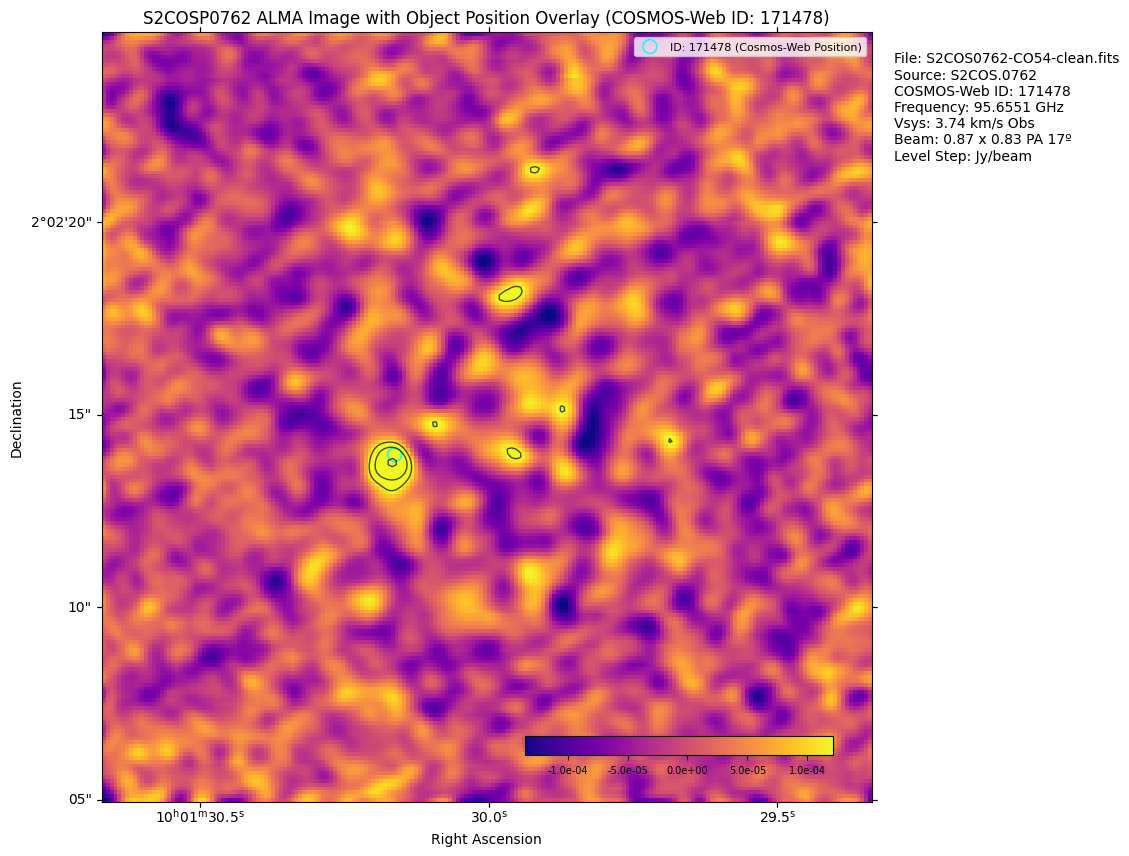

In [21]:
from astropy.visualization import ZScaleInterval
# plot the ALMA image with WCS coordinates, and overlay the position of the object in the condition_detection_reviewed catalog.
# Use the celestial (2D) WCS and a 2D image slice to avoid the "more than 2 pixel dimensions" ValueError.
alma_img_2d = np.squeeze(s2cos0762_alma_image)  # remove singleton spectral axis if present
fig, ax = plt.subplots(figsize=(10, 10), subplot_kw={'projection': s2cos0762_alma_wcs.celestial})
interval = ZScaleInterval()
vmin, vmax = interval.get_limits(alma_img_2d)
ax.imshow(alma_img_2d, origin='lower', cmap='plasma', vmin=vmin, vmax=vmax,)

#draw contour lines at 3, 5, 10, 20 sigma above the background noise level, where the background noise level is estimated as the standard deviation of the pixel values in a region of the image that does not contain any sources.

#set background_noise_level to be the standard devation of the image after we mask out 3 sigma pixels above the first estimate of the background noise level
background_noise_level = np.std(alma_img_2d)
mask = alma_img_2d < 3 * background_noise_level
background_noise_level = np.std(alma_img_2d[mask])
contour_levels = [3 * background_noise_level, 5 * background_noise_level, 9 * background_noise_level, 11 * background_noise_level]
ax.contour(alma_img_2d, levels=contour_levels, colors='black', linewidths=1, alpha=0.7)

obj = next((o for o in catalogHandler.get_cat_photom('condition_detection_reviewed') if o['id'] == COSMOS_WEB_ID), None)
if obj is not None:
    ra, dec = obj['ra'], obj['dec']
    # plot marker in world coordinates (RA, Dec) so the WCSAxes places it correctly
    ax.scatter(ra, dec, transform=ax.get_transform('world'),
               s=100, edgecolor='cyan', facecolor='none',
               label=f"ID: {obj['id']} (Cosmos-Web Position)")
    ax.legend(loc='upper right', fontsize=8)
    
    ax.set_xlabel('Right Ascension')
    ax.set_ylabel('Declination')
    
    #include colorbar for the image intensity values
    from mpl_toolkits.axes_grid1 import make_axes_locatable
    import matplotlib.axes as maxes
    from matplotlib.ticker import FuncFormatter
    divider = make_axes_locatable(ax)
    # cax = divider.append_axes("right", size="5%", pad=0.1)
    # cax = divider.append_axes("right", size="5%", pad=0.1, axes_class=maxes.Axes)  # <- key
    # cbar = plt.colorbar(ax.images[0], cax=cax,#None,#cax,
    #                 format=FuncFormatter(lambda x, _: f"{x:.1e}"))
    # [x0, y0, width, height] in axes fractions (0–1). Bottom-right, small.
    cax = ax.inset_axes([0.55, 0.06, 0.4, 0.025])
    cbar = plt.colorbar(ax.images[0], cax=cax, orientation='horizontal',
                        format=FuncFormatter(lambda x, _: f"{x:.1e}"))
    cbar.ax.tick_params(labelsize=7)          # small tick labels

#include data info on right side of the plot including info about file, source, header information like frequency, vsys, beam, level step, and any other relevant information from the header. Use a text box to display this information in a readable format.
filename = str(S2COSP0762_ALMA_CLEAN).split('/')[-1]
#convert beam from degrees to arcsec
beam_maj_arcsec = s2cos0762_alma_header.get('BMAJ', 'N/A') * 3600 if s2cos0762_alma_header.get('BMAJ', 'N/A') != 'N/A' else 'N/A'
beam_min_arcsec = s2cos0762_alma_header.get('BMIN', 'N/A') * 3600 if s2cos0762_alma_header.get('BMIN', 'N/A') != 'N/A' else 'N/A'
#beam PA in degrees
beam_pa_deg = s2cos0762_alma_header.get('BPA', 'N/A') if s2cos0762_alma_header.get('BPA', 'N/A') != 'N/A' else 'N/A'
frequency = s2cos0762_alma_header.get('ALTRVAL', 'N/A') if s2cos0762_alma_header.get('ALTRVAL', 'N/A') != 'N/A' else 'N/A'
#convert frequency to GHz
frequency_ghz = frequency / 1e9 if frequency != 'N/A' else 'N/A'

header_info = f"File: {filename}\nSource: {ALMA_ID}\nCOSMOS-Web ID: {COSMOS_WEB_ID}\nFrequency: {frequency_ghz:.4f} GHz\nVsys: {s2cos0762_alma_header.get('VELO-OBS', 'N/A')/1e3:.2f} km/s Obs\nBeam: {beam_maj_arcsec:.2f} x {beam_min_arcsec:.2f} PA {beam_pa_deg:.2g}º\nLevel Step: {s2cos0762_alma_header.get('BUNIT', 'N/A')}\n"
props = dict(boxstyle='round', facecolor='white', alpha=0.8)

fig = ax.figure
# cbar_pos = cax.get_position()
# fig.text(
#     cbar_pos.x1 + 0.02,
#     cbar_pos.y0 + cbar_pos.height - 0.1,#/ 2,
#     header_info,
#     transform=fig.transFigure,
#     fontsize=10,
#     va='center',
#     ha='left',
#     # bbox=props,
# )
#instead put header_info in the top on the right side of the plot in the whitespace
plot_pos = ax.get_position()
fig.text(
    plot_pos.x1 + 0.02,
    plot_pos.y0 + plot_pos.height - 0.02,
    header_info,
    transform=fig.transFigure,
    fontsize=10,
    va='top',
    ha='left',
    # bbox=props,
)

ax.set_title(f"S2COSP0762 ALMA Image with Object Position Overlay (COSMOS-Web ID: {COSMOS_WEB_ID})")
plt.show()

# SED Fit

In [11]:
#for all of the condition_detection_reviewed, print in the following format:
# Object 1/29 : ID 17338 , RA, DEC
for i, obj in enumerate(catalogHandler.get_cat_photom('condition_detection_reviewed')):
    obj_id = obj['id']
    ra, dec = obj['ra'], obj['dec']
    tile = obj['tile']
    print(f"Object {i+1}/{len(catalogHandler.get_cat_photom('condition_detection_reviewed'))} : ID {obj_id} , RA, DEC {ra:.6f} {dec:.6f} , Tile {tile}")

Object 1/29 : ID 17338 , RA, DEC 149.826836 2.239005 , Tile A1
Object 2/29 : ID 26910 , RA, DEC 149.820874 2.307251 , Tile A1
Object 3/29 : ID 56404 , RA, DEC 149.909220 2.211260 , Tile A2
Object 4/29 : ID 79810 , RA, DEC 150.039343 2.051379 , Tile A3
Object 5/29 : ID 92586 , RA, DEC 150.063441 2.135579 , Tile A3
Object 6/29 : ID 96066 , RA, DEC 150.102117 2.143862 , Tile A3
Object 7/29 : ID 136802 , RA, DEC 150.305498 2.070558 , Tile A4
Object 8/29 : ID 167591 , RA, DEC 150.390583 1.995666 , Tile A5
Object 9/29 : ID 171478 , RA, DEC 150.375679 2.037211 , Tile A5
Object 10/29 : ID 183201 , RA, DEC 150.346119 1.989711 , Tile A5
Object 11/29 : ID 184688 , RA, DEC 150.304084 2.050700 , Tile A5
Object 12/29 : ID 291236 , RA, DEC 150.038611 1.990003 , Tile A8
Object 13/29 : ID 333050 , RA, DEC 150.202186 1.948589 , Tile A9
Object 14/29 : ID 334444 , RA, DEC 150.148610 1.978487 , Tile A9
Object 15/29 : ID 369896 , RA, DEC 150.342839 1.893590 , Tile A10
Object 16/29 : ID 384271 , RA, DEC 150.

#### stack images

In [52]:
stack_sample = catalogHandler.get_cat_photom('condition_detection_reviewed')
# mask out stack_sample['id'] == 17338 or stack_sample['id'] == 171478
id_mask = catalogHandler.get_filter_cut(filtername='condition_stacking_sample', filter_to_take_from='condition_detection_reviewed', filter_func=lambda cat_photom, cat_lephare, cat_cigale, cat_bd : np.logical_and(cat_photom['id'] != 17338, cat_photom['id'] != 171478))

aperature = CosmosWebApertureEnum.APER_0p5.value
strict_pure_277_dropout = catalogHandler.get_filter_cut(filtername='condition_strict_pure_277_dropout', filter_to_take_from='condition_detection_reviewed', filter_func=lambda cat_photom, cat_lephare, cat_cigale, cat_bd :  
    (np.asarray(cat_photom['flux_aper_f277w'])[:, aperature] / np.asarray(cat_photom['flux_err_aper_f277w'])[:, aperature] < 2)
    & (np.asarray(cat_photom['flux_aper_f115w'])[:, aperature] / np.asarray(cat_photom['flux_err_aper_f115w'])[:, aperature] < 2)
    & (np.asarray(cat_photom['flux_aper_f150w'])[:, aperature] / np.asarray(cat_photom['flux_err_aper_f150w'])[:, aperature] < 2)
    & (np.asarray(cat_photom['flux_aper_f444w'])[:, aperature] / np.asarray(cat_photom['flux_err_aper_f444w'])[:, aperature] >= 5)
    & (np.asarray(cat_photom['flux_aper_f770w'])[:, aperature] / np.asarray(cat_photom['flux_err_aper_f770w'])[:, aperature] >= 5))

# # print the id's that are in the strict_pure_277_dropout filter
# print("IDs in strict_pure_277_dropout filter:")
# for obj in catalogHandler.get_cat_photom('condition_detection_reviewed')[strict_pure_277_dropout]:
#     print(obj['id'])

use_purity_dropout_for_stacking = False
if use_purity_dropout_for_stacking:
    stack_sample_filtername = 'condition_strict_pure_277_dropout'
else:
    stack_sample_filtername = 'condition_stacking_sample'

Filter cut: 27 out of 29 objects remain. Fraction: 93.10%
Filter cut: 14 out of 29 objects remain. Fraction: 48.28%


In [53]:
# STACK_COSMOS_WEB_FW = '/Volumes/Sandisk/dusty-red/cosmosweb-mosiac/'
STACK_COSMOS_WEB_FW = f'{PATH_PREFIX}/data/cosmosweb-mosiac/'

from enum import Enum
from astropy.nddata import Cutout2D

class StackCosmosWebFW(Enum):
    F115W = 'F115W'
    F150W = 'F150W'
    F277W = 'F277W'
    F444W = 'F444W'
    F770W = 'F770W'

def _science_hdu(hdul):
    """Return (data2d, celestial_wcs) for the first HDU that holds a 2-D image with a
    sky WCS. JWST *_i2d mosaics keep the image + WCS in the 'SCI' extension, not the
    primary HDU, and some mosaics omit CUNIT (which breaks angular-size cutouts)."""
    for h in hdul:
        if h.data is None:
            continue
        w = WCS(h.header)
        if w.has_celestial:
            wc = w.celestial
            if any(str(cu) == '' for cu in wc.wcs.cunit):   # FITS RA/DEC TAN axes are in degrees
                wc.wcs.cunit = ['deg', 'deg']
            return np.squeeze(h.data), wc
    raise ValueError('no 2-D celestial image HDU found')


#### make cutouts if needed

In [39]:
# example image file path: /Volumes/Sandisk/dusty-red/cosmosweb-mosiac/{band}/mosaic_nircam_{band}_COSMOS-Web_60mas_{tile}_v1.0_i2d.fits(.gz)
# For each detection, use the object's tile to grab a 10x10 arcsec cutout in each band with
# astropy.nddata.Cutout2D, and save it to {band}/cutouts/{objectID}_{band}_cutout.fits
for i, obj in enumerate(catalogHandler.get_cat_photom('condition_detection_reviewed')):
    # if i > 0:
    #     break
    obj_id = obj['id']
    ra, dec = obj['ra'], obj['dec']
    tile = obj['tile']
    position = SkyCoord(ra * u.deg, dec * u.deg)   # sky position; a plain (ra, dec) tuple is read as PIXELS
    for band in StackCosmosWebFW:
        b = str(band.value).lower()
        if band == StackCosmosWebFW.F770W:
            base = f"{STACK_COSMOS_WEB_FW}{b}/mosaic_miri_{b}_COSMOS-Web_60mas_{tile}_v1.0_i2d.fits"
            image_file_path = next((c for c in (base, base + '.gz') if os.path.exists(c)), None)
        else:
            base = f"{STACK_COSMOS_WEB_FW}{b}/mosaic_nircam_{b}_COSMOS-Web_60mas_{tile}_v1.0_i2d.fits"
            image_file_path = next((c for c in (base, base + '.gz') if os.path.exists(c)), None)
        if image_file_path is None:
            print(f"Image file {base}[.gz] does not exist. Skipping cutout for object {obj_id} in band {band.value}.")
            continue
        with fits.open(image_file_path) as hdul:
            data, wcs = _science_hdu(hdul)
            cutout = Cutout2D(data, position=position, size=(10 * u.arcsec, 10 * u.arcsec), wcs=wcs)
        cutout_file_path = f"{STACK_COSMOS_WEB_FW}{b}/cutouts/{obj_id}_{b}_cutout.fits"
        os.makedirs(os.path.dirname(cutout_file_path), exist_ok=True)
        hdu = fits.PrimaryHDU(data=cutout.data, header=cutout.wcs.to_header())
        hdu.writeto(cutout_file_path, overwrite=True)
        print(f"Saved cutout for object {obj_id} in band {band.value} to {cutout_file_path}.")


Image file /Volumes/Apple SDXC Reader Media/dusty-red/data/cosmosweb-mosiac/f115w/mosaic_nircam_f115w_COSMOS-Web_60mas_A1_v1.0_i2d.fits[.gz] does not exist. Skipping cutout for object 17338 in band F115W.
Image file /Volumes/Apple SDXC Reader Media/dusty-red/data/cosmosweb-mosiac/f150w/mosaic_nircam_f150w_COSMOS-Web_60mas_A1_v1.0_i2d.fits[.gz] does not exist. Skipping cutout for object 17338 in band F150W.
Image file /Volumes/Apple SDXC Reader Media/dusty-red/data/cosmosweb-mosiac/f277w/mosaic_nircam_f277w_COSMOS-Web_60mas_A1_v1.0_i2d.fits[.gz] does not exist. Skipping cutout for object 17338 in band F277W.
Image file /Volumes/Apple SDXC Reader Media/dusty-red/data/cosmosweb-mosiac/f444w/mosaic_nircam_f444w_COSMOS-Web_60mas_A1_v1.0_i2d.fits[.gz] does not exist. Skipping cutout for object 17338 in band F444W.
Image file /Volumes/Apple SDXC Reader Media/dusty-red/data/cosmosweb-mosiac/f770w/mosaic_miri_f770w_COSMOS-Web_60mas_A1_v1.0_i2d.fits[.gz] does not exist. Skipping cutout for objec

#### make masks and plot

In [54]:
#take all the cutouts for each object and band, and mask out bright objects that are not the target object, using a sigma clipping method to identify and mask out pixels that are more than 3 sigma above the median pixel value in the cutout. Save the masked cutouts to a new fits file in the following format: /Volumes/Sandisk/dusty-red/cosmosweb-mosiac/{band}/cutouts/masked/{objectID}_{band}_masked_cutout.fits

for i, obj in enumerate(catalogHandler.get_cat_photom(stack_sample_filtername)):
    # if i > 0:
    #     break
    obj_id = obj['id']
    ra, dec = obj['ra'], obj['dec']
    tile = obj['tile']
    position = SkyCoord(ra * u.deg, dec * u.deg)   # sky position; a plain (ra, dec) tuple is read as PIXELS
    for band in StackCosmosWebFW:
        cutout_file_path = f"{STACK_COSMOS_WEB_FW}{str(band.value).lower()}/cutouts/{obj_id}_{str(band.value).lower()}_cutout.fits"
        if not os.path.exists(cutout_file_path):
            print(f"Cutout file {cutout_file_path} does not exist. Skipping masking for object {obj_id} in band {band.value}.")
            continue
        with fits.open(cutout_file_path) as hdul:
            data = hdul[0].data
            # exclude the values near the center of the cutout (the target object) from the sigma clipping, by masking out a circular region of radius 1 arcsec around the center of the cutout. Use the WCS information in the cutout header to convert 1 arcsec to pixels.
            data_masked_center = np.copy(data)
            cutout_wcs = WCS(hdul[0].header)
            center_pixel = cutout_wcs.world_to_pixel(position)
            pixscale_arcsec = cutout_wcs.proj_plane_pixel_scales()[0].to(u.arcsec).value
            radius_pix = 1.0 / pixscale_arcsec
            y, x = np.indices(data.shape)
            r = np.sqrt((x - center_pixel[0])**2 + (y - center_pixel[1])**2)
            data_masked_center[r < radius_pix] = np.nan
            
            median = np.median(data_masked_center[~np.isnan(data_masked_center)])
            std = np.std(data_masked_center[~np.isnan(data_masked_center)])
            mask = data_masked_center > (median + 2 * std)
            masked_data = np.copy(data)
            masked_data[mask] = np.nan
            print(f"Masked out {np.sum(mask)} pixels out of {data.size} in cutout for object {obj_id} in band {band.value}.")
            masked_cutout_file_path = f"{STACK_COSMOS_WEB_FW}{str(band.value).lower()}/cutouts/masked/{obj_id}_{str(band.value).lower()}_masked_cutout.fits"
            if not os.path.exists(os.path.dirname(masked_cutout_file_path)):
                print(f"Creating directory {os.path.dirname(masked_cutout_file_path)} for masked cutouts.")
                os.makedirs(os.path.dirname(masked_cutout_file_path), exist_ok=True)
                
            hdu = fits.PrimaryHDU(data=masked_data, header=hdul[0].header)
            hdu.writeto(masked_cutout_file_path, overwrite=True)
            print(f"Saved masked cutout for object {obj_id} in band {band.value} to {masked_cutout_file_path}.")
            

Masked out 18 pixels out of 27889 in cutout for object 26910 in band F115W.
Saved masked cutout for object 26910 in band F115W to /Volumes/Apple SDXC Reader Media/dusty-red/data/cosmosweb-mosiac/f115w/cutouts/masked/26910_f115w_masked_cutout.fits.
Masked out 22 pixels out of 27889 in cutout for object 26910 in band F150W.
Saved masked cutout for object 26910 in band F150W to /Volumes/Apple SDXC Reader Media/dusty-red/data/cosmosweb-mosiac/f150w/cutouts/masked/26910_f150w_masked_cutout.fits.
Masked out 84 pixels out of 27889 in cutout for object 26910 in band F277W.
Saved masked cutout for object 26910 in band F277W to /Volumes/Apple SDXC Reader Media/dusty-red/data/cosmosweb-mosiac/f277w/cutouts/masked/26910_f277w_masked_cutout.fits.
Masked out 166 pixels out of 27889 in cutout for object 26910 in band F444W.
Saved masked cutout for object 26910 in band F444W to /Volumes/Apple SDXC Reader Media/dusty-red/data/cosmosweb-mosiac/f444w/cutouts/masked/26910_f444w_masked_cutout.fits.
Masked 

In [55]:
#take the masked cutouts for each object and band, stack them together to create a median stacked image for each band, and save the stacked images to a new fits file in the following format: /Volumes/Sandisk/dusty-red/cosmosweb-mosiac/{band}/stacked/{band}_stacked.fits

for band in StackCosmosWebFW:
    masked_cutouts = []
    for i, obj in enumerate(catalogHandler.get_cat_photom(stack_sample_filtername)):
        # if i > 0:
        #     break
        obj_id = obj['id']
        masked_cutout_file_path = f"{STACK_COSMOS_WEB_FW}{str(band.value).lower()}/cutouts/masked/{obj_id}_{str(band.value).lower()}_masked_cutout.fits"
        if not os.path.exists(masked_cutout_file_path):
            print(f"Masked cutout file {masked_cutout_file_path} does not exist. Skipping stacking for band {band.value}.")
            continue
        with fits.open(masked_cutout_file_path) as hdul:
            masked_cutouts.append(hdul[0].data)
    if len(masked_cutouts) == 0:
        print(f"No masked cutouts found for band {band.value}. Skipping stacking.")
        continue
    stacked_data = np.nanmedian(np.array(masked_cutouts), axis=0)
    stacked_file_path = f"{STACK_COSMOS_WEB_FW}{str(band.value).lower()}/stacked/{str(band.value).lower()}_stacked.fits"
    if not os.path.exists(os.path.dirname(stacked_file_path)):
        print(f"Creating directory {os.path.dirname(stacked_file_path)} for stacked images.")
        os.makedirs(os.path.dirname(stacked_file_path), exist_ok=True)
    hdu = fits.PrimaryHDU(data=stacked_data, header=hdul[0].header)
    hdu.writeto(stacked_file_path, overwrite=True)
    print(f"Saved stacked image for band {band.value} to {stacked_file_path}.")
    


Saved stacked image for band F115W to /Volumes/Apple SDXC Reader Media/dusty-red/data/cosmosweb-mosiac/f115w/stacked/f115w_stacked.fits.
Saved stacked image for band F150W to /Volumes/Apple SDXC Reader Media/dusty-red/data/cosmosweb-mosiac/f150w/stacked/f150w_stacked.fits.
Saved stacked image for band F277W to /Volumes/Apple SDXC Reader Media/dusty-red/data/cosmosweb-mosiac/f277w/stacked/f277w_stacked.fits.
Saved stacked image for band F444W to /Volumes/Apple SDXC Reader Media/dusty-red/data/cosmosweb-mosiac/f444w/stacked/f444w_stacked.fits.
Saved stacked image for band F770W to /Volumes/Apple SDXC Reader Media/dusty-red/data/cosmosweb-mosiac/f770w/stacked/f770w_stacked.fits.


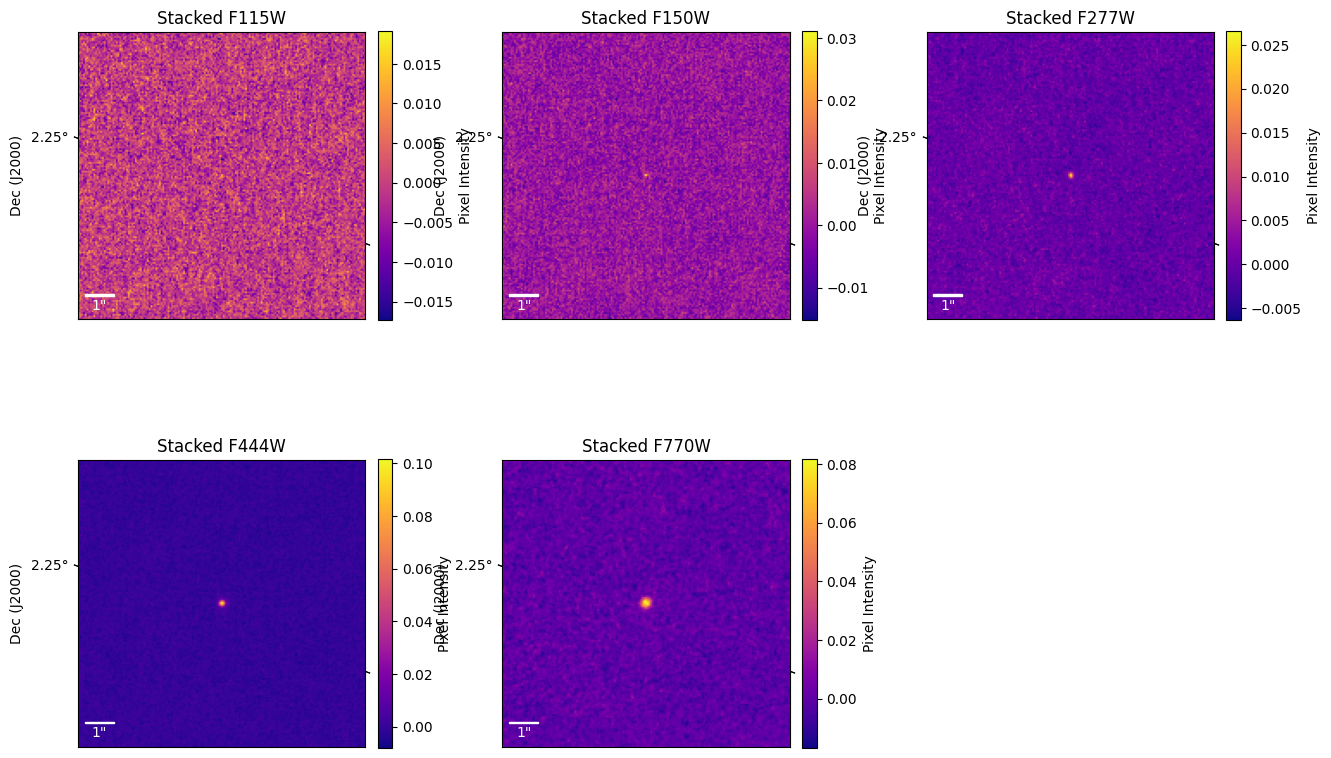

In [56]:
# Display the stacked images in a 2x3 grid, one band per panel, with real RA/Dec axes
# (from each stacked image's WCS), a colorbar, and an angular scale bar.
# NOTE: include_scale_bar() ends with ax.axis('off'), which would hide the RA/Dec ticks,
# so we draw the scale bar with AnchoredSizeBar instead (it coexists with WCS axes).
# Also note: the stack inherits the WCS of the reference cutout, so absolute RA/Dec is only
# physically meaningful when stacking a single object (as configured upstream).
from mpl_toolkits.axes_grid1.anchored_artists import AnchoredSizeBar

fig = plt.figure(figsize=(15, 10))
for i, band in enumerate(StackCosmosWebFW):
    stacked_file_path = f"{STACK_COSMOS_WEB_FW}{str(band.value).lower()}/stacked/{str(band.value).lower()}_stacked.fits"
    if not os.path.exists(stacked_file_path):
        print(f"Stacked file {stacked_file_path} does not exist. Skipping display for band {band.value}.")
        continue
    with fits.open(stacked_file_path) as hdul:
        data = np.squeeze(hdul[0].data)
        wcs = WCS(hdul[0].header).celestial

    ax = fig.add_subplot(2, 3, i + 1, projection=wcs)
    im = ax.imshow(data, origin='lower', cmap='plasma')
    ax.set_title(f"Stacked {band.value}")
    ax.set_xlabel('RA (J2000)')
    ax.set_ylabel('Dec (J2000)')
    # ax.coords[0].set_major_formatter('hh:mm:ss.s')
    # ax.coords[1].set_major_formatter('dd:mm:ss')

    #set in degrees with 2 decimal places
    ax.coords[0].set_major_formatter('d.dd')
    ax.coords[1].set_major_formatter('d.dd')

    cbar = fig.colorbar(im, ax=ax, orientation='vertical', fraction=0.046, pad=0.04)
    cbar.set_label('Pixel Intensity')

    # 1 arcsec scale bar (convert to pixels via the WCS pixel scale)
    pixscale_arcsec = wcs.proj_plane_pixel_scales()[0].to(u.arcsec).value
    bar_arcsec = 1.0
    bar = AnchoredSizeBar(ax.transData, bar_arcsec / pixscale_arcsec, f'{bar_arcsec:g}"',
                          'lower left', pad=0.4, color='white', frameon=False, size_vertical=1)
    ax.add_artist(bar)

fig.subplots_adjust(wspace=0.35, hspace=0.25)
plt.show()


In [58]:
# with the stacked images, get the peak flux density within 1 arcsec of the center and the stdev of the background in 5 arcsec, making sure to mask out bright signal after a first pass and then recompute stdev

stacked_table_data = []
for band in StackCosmosWebFW:
    stacked_file_path = f"{STACK_COSMOS_WEB_FW}{str(band.value).lower()}/stacked/{str(band.value).lower()}_stacked.fits"
    if not os.path.exists(stacked_file_path):
        print(f"Stacked file {stacked_file_path} does not exist. Skipping peak flux density measurement for band {band.value}.")
        continue
    with fits.open(stacked_file_path) as hdul:
        data = np.squeeze(hdul[0].data)
        wcs = WCS(hdul[0].header).celestial
        # get the center pixel coordinates
        center_pixel = (data.shape[1] / 2, data.shape[0] / 2)
        # convert 1 arcsec to pixels via the WCS pixel scale
        pixscale_arcsec = wcs.proj_plane_pixel_scales()[0].to(u.arcsec).value
        radius_pix = 1.0 / pixscale_arcsec
        # convert 5 arcsec to pixels via the WCS pixel scale
        background_radius_pix = 5.0 / pixscale_arcsec
        y, x = np.indices(data.shape)
        r = np.sqrt((x - center_pixel[0])**2 + (y - center_pixel[1])**2)
        mask = r <= radius_pix
        peak_flux_density = np.nanmax(data[mask])
        ra_dec_center = wcs.pixel_to_world(center_pixel[0], center_pixel[1])
        
        mask_background = r <= background_radius_pix
        # mask out the bright signal in the background region (anything above 3 sigma of the background)
        background_data = data[mask_background]
        background_median = np.nanmedian(background_data)
        background_std = np.nanstd(background_data)
        mask_bright_signal = background_data > (background_median + 3 * background_std)
        background_data_masked = background_data[~mask_bright_signal]
        background_std_final = np.nanstd(background_data_masked)
        
        stacked_table_data.append((band.value, peak_flux_density, ra_dec_center.ra.deg, ra_dec_center.dec.deg, background_std_final))



# Print the table
print("Band\tPeak Flux Density, Stdev")# \tRA\tDec")
for row in stacked_table_data:
    print(f"{row[0]}\t{row[1]}\t{row[4]}")# \t{row[2]}\t{row[3]}")

Band	Peak Flux Density, Stdev
F115W	0.013108926825225353	0.004214215558022261
F150W	0.031075146049261093	0.003446477698162198
F277W	0.026561656966805458	0.0014607732882723212
F444W	0.10166948288679123	0.0017974681686609983
F770W	0.08174985950911318	0.003891661414273166


#### create supertable

In [61]:
# create a table which consolidates the flux measurements from JWST and radio (VLA 3Ghz, CHAMPS, ALMA, Superdeblended)
#will eventually CIGALE SED fit

# CIGALE naming conventions: 
# File containing the input data. The columns are:
# * 'id': name of the object.
# * 'redshift': redshift of the object. If 0, the distance is assumed to
# be 10 pc. If negative the photometric mode is enabled. In that case an
# explicit redshift grid must be provided in the redshfting module.
# * 'distance' (Mpc, optional): distance in Mpc. Optional, if present it
# will be used in lieu of the distance computed from the redshift
# assuming a Planck et al. (2018) cosmology.
# * band fluxes: fluxes in filters in mJy. Each column is identified
# with a unique filter name, for instance jwst.nircam.F200W for the 2 μm
# filter of the NIRCAM instrument onboard JWST. The known filters are
# avalaible from the command 'pcigale-filters list'.
# * line fluxes: fluxes in lines in W/m². Each column is identified
# after a unique line name prefixed with 'line.', for instance
# line.H-alpha. The known filters are available from the command
# 'pcigale-filters list'. It is possible to combine lines together, for
# instance line.NII-654.8+H-alpha+NII-658.3 will be the sum of Hα and
# the adjacent NII lines.
# * physical properties: values of the intensive and extensive physical
# properties (e.g., dust.luminosity for the dust luminosity). To
# determine the format of the columns and the units, it is suggested to
# do a minimal run and examine the output FITS table.
# * uncertainties: the uncertainties for the band and line fluxes as
# well as for the physical properties are given using the same column
# names with the '_err' suffix.
# Important notes:
# * Fluxes can be positive or negative.
# * Upper limits are indicated with a negative value for the
# uncertainty.
# * In case some fluxes are missing for some objects, they can be
# replaced with NaN.
# * This file is optional to generate the configuration file, in
# particular for the savefluxes module.
super_table = Table(
    names=('id', 'redshift', 'RA', 'DEC',
           'jwst.nircam.F115W', 'jwst.nircam.F115W_err',
           'jwst.nircam.F150W', 'jwst.nircam.F150W_err',
           'jwst.nircam.F277W', 'jwst.nircam.F277W_err',
           'jwst.nircam.F444W', 'jwst.nircam.F444W_err',
           'jwst.miri.F770W',   'jwst.miri.F770W_err',
           # custom-registered filters:
           'vla.S',      'vla.S_err',
           'alma.A3Band3', 'alma.A3Band3_err',
           'alma.champs',     'alma.champs_err',
           'superdeblendedF24', 'superdeblendedF24_err',
           'superdeblendedF100', 'superdeblendedF100_err',
           'superdeblendedF160', 'superdeblendedF160_err',
           ),
    dtype=('i4', 'f8', 'f8', 'f8',
           'f4','f4', 'f4','f4', 'f4','f4', 'f4','f4', 'f4','f4',
           'f4','f4', 'f4','f4', 'f4', 'f4', 'f4', 'f4', 'f4', 'f4', 'f4', 'f4'),
    meta={'name': 'Super Table of Flux Measurements from JWST and Radio'},
)

DUSTY_RED_GALAXY_ID = 171478
DUSTY_RED_GALAXY_ID2 = 183201
stacked_images = True

# for i, obj in enumerate(catalogHandler.get_cat_photom('condition_detection_reviewed')[catalogHandler.get_cat_photom('condition_detection_reviewed')['id'] == DUSTY_RED_GALAXY_ID]):
# for i, obj in enumerate(catalogHandler.get_cat_photom('condition_detection_reviewed')[catalogHandler.get_cat_photom('condition_detection_reviewed')['id'] == DUSTY_RED_GALAXY_ID2]):
for i, obj in enumerate(catalogHandler.get_cat_photom('condition_detection_reviewed')):
       if not stacked_images:
              obj_id = obj['id']
              ra, dec = obj['ra'], obj['dec']
              redshift = catalogHandler.get_z_redshift('condition_detection_reviewed')[catalogHandler.get_cat_photom('condition_detection_reviewed')['id'] == obj_id][0]
              #JWST fluxes in mJy, with errors
              # print(catalogHandler.get_filter_flux_of_id(obj_id, 'condition_detection_reviewed', 'f115w'))
              f115, f115_err = catalogHandler.get_filter_flux_of_id(obj_id, 'condition_detection_reviewed', 'f115w', useModel=True)[0], catalogHandler.get_filter_flux_of_id(obj_id, 'condition_detection_reviewed', 'f115w', useModel=True)[1] # fluxes in microJy
              f150, f150_err = catalogHandler.get_filter_flux_of_id(obj_id, 'condition_detection_reviewed', 'f150w', useModel=True)[0], catalogHandler.get_filter_flux_of_id(obj_id, 'condition_detection_reviewed', 'f150w', useModel=True)[1] # fluxes in microJy
              f277, f277_err = catalogHandler.get_filter_flux_of_id(obj_id, 'condition_detection_reviewed', 'f277w', useModel=True)[0], catalogHandler.get_filter_flux_of_id(obj_id, 'condition_detection_reviewed', 'f277w', useModel=True)[1] # fluxes in microJy
              f444w, f444w_err = catalogHandler.get_filter_flux_of_id(obj_id, 'condition_detection_reviewed', 'f444w', useModel=True)[0], catalogHandler.get_filter_flux_of_id(obj_id, 'condition_detection_reviewed', 'f444w', useModel=True)[1] # fluxes in microJy
              f770w, f770w_err = catalogHandler.get_filter_flux_of_id(obj_id, 'condition_detection_reviewed', 'f770w', useModel=True)[0], catalogHandler.get_filter_flux_of_id(obj_id, 'condition_detection_reviewed', 'f770w', useModel=True)[1] # fluxes in microJy
              
              #convert to mJy
              f115, f115_err = f115 / 1000, f115_err / 1000
              f150, f150_err = f150 / 1000, f150_err / 1000
              f277, f277_err = f277 / 1000, f277_err / 1000
              f444w, f444w_err = f444w / 1000, f444w_err / 1000
              f770w, f770w_err = f770w / 1000, f770w_err / 1000
              
              
              #if object is 171478, include super-deblended match
              if obj_id == DUSTY_RED_GALAXY_ID:
                     matched_super_deblended_row = matched_super_deblended[obj_id]
                     if len(matched_super_deblended_row) > 0:
                            f24, f24_err = matched_super_deblended_row['f24'], matched_super_deblended_row['df24'] # in microJy
                            f100, f100_err = matched_super_deblended_row['f100'], matched_super_deblended_row['df100'] # in microJy
                            f160, f160_err = matched_super_deblended_row['f160'], matched_super_deblended_row['df160'] # in microJy
                            
                            #convert to mJy
                            f24, f24_err = f24 / 1000, f24_err / 1000
                            # f100, f100_err = f100 / 1000, f100_err / 1000
                            # f160, f160_err = f160 / 1000, f160_err / 1000
                     else:
                            f24, f24_err = np.nan, np.nan
                            f100, f100_err = np.nan, np.nan
                            f160, f160_err = np.nan, np.nan
              else:
                     f24, f24_err = np.nan, np.nan
                     f100, f100_err = np.nan, np.nan
                     f160, f160_err = np.nan, np.nan
              
              #dict stores the object id as key, and a tuple of (ok_detection, intensity_point, intensity_avg, intensity_peak, stdev_value, rms_value) as value
              # VLA 3Ghz data is in Jy/Beam
              if matched_vla.get(obj_id) is not None and matched_vla[obj_id][0]:
                     vla_flux, vla_flux_err = matched_vla[obj_id][3] * 1000, matched_vla[obj_id][4] * 1000
              else:
                     vla_flux, vla_flux_err = matched_vla[obj_id][3] * 1000, matched_vla[obj_id][4] * 1000
              
              # champs data is in Jy/Beam
              if matched_champs_image.get(obj_id) is not None and matched_champs_image[obj_id][0]:
                     # print(matched_champs_image[obj_id])
                     champs_flux, champs_flux_err = matched_champs_image[obj_id][3] * 1000, matched_champs_image[obj_id][4] * 1000
              else:
                     champs_flux, champs_flux_err = matched_champs_image[obj_id][3] * 1000, matched_champs_image[obj_id][4] * 1000
              
              # ALMA A3 data is in mJy/Beam
              if matched_almaA3_prior.get(obj_id) is not None and matched_almaA3_prior[obj_id][0]:
                     print(f"Matched ALMA A3 prior for object {obj_id}: ")#{matched_almaA3_prior[obj_id]}")
                     # matched_almaA3_prior[obj_id] is an astropy.table.Row; convert to a Table (or dict) before printing
                     print(Table([matched_almaA3_prior[obj_id]]).to_pandas())
                     almaA3_flux, almaA3_flux_err = matched_almaA3_prior[obj_id]['Total_flux_pbcor'], matched_almaA3_prior[obj_id]['E_Total_flux_pbcor'] * 1
                     print(f"Observed ALMA A3 frequency for object {obj_id}: {micron_wavelength_to_frequency(matched_almaA3_prior[obj_id]['Obs_wavelength']) / 1e9:.4f} GHz")
              else:
                     print(f"No matched ALMA A3 prior for object {obj_id}. Setting flux and error to NaN.")
                     almaA3_flux, almaA3_flux_err = np.nan, np.nan #matched_almaA3_prior[obj_id]['Total_flux_pbcor'], matched_almaA3_prior[obj_id]['E_Total_flux_pbcor'] * -1
       else:
            #using stacked images;  grab from stacked_table_data the five jwst filters. leave the radio fluxes as NaN for now, since we don't have stacked radio images yet.
            obj_id = 0
            ra, dec = np.nan, np.nan
            redshift = np.nan
       #      # Print the table
       #        print("Band\tPeak Flux Density, Stdev")# \tRA\tDec")
       #        for row in stacked_table_data:
       #        print(f"{row[0]}\t{row[1]}\t{row[4]}")# \t{row[2]}\t{row[3]}")
            f115, f115_err = stacked_table_data[0][1], stacked_table_data[0][4]
            f150, f150_err = stacked_table_data[1][1], stacked_table_data[1][4]
            f277, f277_err = stacked_table_data[2][1], stacked_table_data[2][4]
            f444w, f444w_err = stacked_table_data[3][1], stacked_table_data[3][4]
            f770w, f770w_err = stacked_table_data[4][1], stacked_table_data[4][4]
            vla_flux, vla_flux_err = np.nan, np.nan
            almaA3_flux, almaA3_flux_err = np.nan, np.nan
            champs_flux, champs_flux_err = np.nan, np.nan
            f24, f24_err = np.nan, np.nan
            f100, f100_err = np.nan, np.nan
            f160, f160_err = np.nan, np.nan        
              
       # Band 3	~100 GHz	alma.band3
       # Band 4	~145 GHz	alma.band4
       # Band 6	~230 GHz (1.2 mm)	alma.band6
       # Band 7	~345 GHz (870 µm)	alma.band7
       # Band 8	~460 GHz	alma.band8
       
       # show the table of flux measurements for the object
       
       # if confident in jwst redshift, use redshift.
       # otherwise if have a redshift from the CO(5-4) line, use that.
       # else use -1 for the redshift.
       if obj_id == DUSTY_RED_GALAXY_ID:
              redshift = 5.025
       if obj_id == DUSTY_RED_GALAXY_ID2:
              # redshift = 6.5
              redshift = np.nan
       super_table.add_row((obj_id, redshift, ra, dec,
                            f115, f115_err,
                            f150, f150_err,
                            f277, f277_err,
                            f444w, f444w_err,
                            f770w, f770w_err,
                            vla_flux, vla_flux_err,
                            almaA3_flux, almaA3_flux_err,
                            champs_flux, champs_flux_err,
                            f24, f24_err,
                            f100, f100_err,
                            f160, f160_err
                            ))
       
       if stacked_images:
              break
       
# display(HTML(f"""
# <div style="max-height:400px; overflow-y:auto; overflow-x:auto;">
#        {super_table.to_pandas().to_html(index=False)}
# </div>
# """))

#print as pd.dataframe
# import pandas as pd
super_table_df = super_table.to_pandas()
super_table_df

,id,redshift,RA,DEC,jwst.nircam.F115W,jwst.nircam.F115W_err,jwst.nircam.F150W,jwst.nircam.F150W_err,jwst.nircam.F277W,jwst.nircam.F277W_err,...,alma.A3Band3,alma.A3Band3_err,alma.champs,alma.champs_err,superdeblendedF24,superdeblendedF24_err,superdeblendedF100,superdeblendedF100_err,superdeblendedF160,superdeblendedF160_err
0,0,NaN,NaN,NaN,0.013109,0.004214,0.031075,0.003446,0.026562,0.001461,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [ ]:
#save the table to a fits file
# super_table.write('cigale-run/super_table_flux_measurements.fits', overwrite=True)
# super_table.write('cigale-run/super_table_flux_measurements_171478.fits', overwrite=True)
# super_table.write('cigale-run/super_table_flux_measurements_183201.fits', overwrite=True)
super_table.write('cigale-run/super_table_flux_measurements_stacked.fits', overwrite=True)

In [69]:
#run cigale-run/run_cigale.py

#### display cigale results

In [10]:
#get the cigale run's posteriors into a table
CIGALE_RUN_DIR = 'cigale-run/out'
# CIGALE_RUN_DIR = 'cigale-run/20260709_132007_out_171478_best0p75_all_fixed'
CIGALE_RESULTS_FILE = os.path.join(CIGALE_RUN_DIR, 'results.fits')
cigale_results = Table.read(CIGALE_RESULTS_FILE)

#dont include columns which start with 'bayes.'
cigale_results_no_bayes = cigale_results#[[c for c in cigale_results.colnames if not c.startswith('bayes.')]]

row = cigale_results_no_bayes.to_pandas().iloc[0]

params = sorted({c[:-4] if c.endswith('_err') else c for c in row.index})
vals = [row.get(p) for p in params]
errs = [row.get(f'{p}_err') for p in params]

def _fmt(x):
    if x is None:
        return ''
    try:
        if isinstance(x, (list, tuple, np.ndarray)):
            return str(x)
        xf = float(x)
        if np.isnan(xf):
            return ''
        return f"{xf:.4e}"
    except Exception:
        return str(x)

summary = pd.DataFrame({
    'value': [_fmt(v) for v in vals],
    'err':   [_fmt(e) for e in errs],
}, index=params)

with pd.option_context('display.max_rows', None, 'display.float_format', '{:.4g}'.format):
    display(summary)



#take the dust luminosity and convert to SFR using the Kennicutt (1998) relation: SFR [M_sun/yr] = 1.0e-10 * L_IR [L_sun] for a Chabrier IMF. The dust luminosity is in Lsun units, so we can just multiply by 1e-10 to get the SFR in Msun/yr.
dust_luminosity = row.get('best.dust.luminosity') # in watts
print(f"Dust luminosity: {dust_luminosity:.4e} Watts")
dust_luminosity = dust_luminosity / 3.828e26 if dust_luminosity is not None else None # convert to Lsun
sfr = 1.0e-10 * dust_luminosity if dust_luminosity is not None else None
print(f"Dust luminosity: {dust_luminosity:.4e} Lsun")
print(f"Star formation rate (SFR): {sfr:.4e} Msun/yr")

,value,err
bayes.agn.accretion_power,0.0000e+00,0.0000e+00
bayes.agn.fracAGN,0.0000e+00,0.0000e+00
bayes.agn.luminosity,0.0000e+00,0.0000e+00
bayes.alma.A3Band6,1.1845e+00,2.1079e-01
bayes.alma.champs,9.8015e-01,1.7355e-01
bayes.attenuation.Av_BC,1.8297e+03,1.8643e+03
bayes.attenuation.Av_ISM,4.0254e+00,8.0425e-01
bayes.dust.luminosity,1.7477e+39,8.4451e+38
bayes.jwst.miri.F770W,5.1469e-04,3.8083e-05
bayes.jwst.nircam.F115W,1.2065e-07,2.8595e-07


Dust luminosity: 2.1610e+39 Watts
Dust luminosity: 5.6453e+12 Lsun
Star formation rate (SFR): 5.6453e+02 Msun/yr
